## Section 0: Setup

In [ ]:
import sys
import os
import pathlib

ROOT = pathlib.Path().resolve().parent
os.chdir(ROOT)

for p in [str(ROOT), str(ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import load_data
from data_utils import load_clean_main_contract

from backtest_engine import (
    fit_ols_model,
    compute_signals,
    compute_performance_metrics,
    run_parameter_sweep,
    plot_results,
)

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)
print('Setup complete. ROOT:', ROOT)

Setup complete. ROOT: D:\Order Imbalance Research


## Section 1: Data Loading & Feature Engineering

In [ ]:
# 1.1–1.4  Data loading, cleaning, main contract selection, derived columns
COLUMNS = [
    'InstruID', 'TradDay', 'ActionDateTime',
    'BidPrice1', 'BidVolume1', 'BidPrice2', 'BidVolume2',
    'BidPrice3', 'BidVolume3', 'BidPrice4', 'BidVolume4',
    'BidPrice5', 'BidVolume5',
    'AskPrice1', 'AskVolume1', 'AskPrice2', 'AskVolume2',
    'AskPrice3', 'AskVolume3', 'AskPrice4', 'AskVolume4',
    'AskPrice5', 'AskVolume5',
    'Volume', 'Turnover', 'OpenInt',
]

df_main = load_clean_main_contract(
    start_date=20180102,
    end_date=20180629,
    columns=COLUMNS,
    db_path='data/market_data_2018.db',
)
print(f'df_main: {len(df_main):,} rows, {df_main["TradDay"].nunique()} trading days')
print('MidPrice/Spread/session added.')

df_main: 2,483,302 rows, 118 trading days
MidPrice/Spread/session added.


In [ ]:
# 1.5  VOI (Volume Order Imbalance) -- NaN at each session open
def compute_VOI(df: pd.DataFrame) -> pd.Series:
    bid_p, bid_v = df['BidPrice1'], df['BidVolume1']
    ask_p, ask_v = df['AskPrice1'], df['AskVolume1']
    d_bid_p = bid_p.diff()
    d_ask_p = ask_p.diff()
    subtract_bid = bid_v.shift(1).where(d_bid_p == 0, other=0.0)
    delta_VB = (bid_v - subtract_bid) * (d_bid_p >= 0)
    subtract_ask = ask_v.shift(1).where(d_ask_p == 0, other=0.0)
    delta_VA = (ask_v - subtract_ask) * (d_ask_p <= 0)
    voi = (delta_VB - delta_VA).rename('VOI')
    voi.iloc[0] = np.nan
    return voi

df_main['VOI'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(compute_VOI)
)

# 1.6  OIR (Order Imbalance Ratio)
df_main['OIR'] = (
    (df_main['BidVolume1'] - df_main['AskVolume1']) /
    (df_main['BidVolume1'] + df_main['AskVolume1'])
)

# 1.7  MPB (Mid-Price Basis)
def compute_MPB(df: pd.DataFrame) -> pd.Series:
    mid   = df['MidPrice']
    d_vol = df['Volume'].diff()
    d_to  = df['Turnover'].diff()
    avg_trade = (d_to / d_vol / 300).replace([np.inf, -np.inf], np.nan)
    avg_trade = avg_trade.ffill().bfill()
    roll_mid  = mid.rolling(2).mean().fillna(mid.iloc[0])
    return (avg_trade - roll_mid).rename('MPB')

df_main['MPB'] = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(compute_MPB)
)

print(f'VOI NaN  : {df_main["VOI"].isna().sum()}')
print(f'OIR NaN  : {df_main["OIR"].isna().sum()}')
print(f'MPB NaN  : {df_main["MPB"].isna().sum()}')

VOI NaN  : 236
OIR NaN  : 0
MPB NaN  : 0


In [ ]:
# 1.8  CostToTrade (5-lot market impact, vectorised book-walk)
TARGET_VOLUME = 5

ask_vols_arr   = df_main[['AskVolume1','AskVolume2','AskVolume3','AskVolume4','AskVolume5']].values
ask_prices_arr = df_main[['AskPrice1', 'AskPrice2', 'AskPrice3', 'AskPrice4', 'AskPrice5']].values
bid_vols_arr   = df_main[['BidVolume1','BidVolume2','BidVolume3','BidVolume4','BidVolume5']].values
bid_prices_arr = df_main[['BidPrice1', 'BidPrice2', 'BidPrice3', 'BidPrice4', 'BidPrice5']].values
mid_vals       = df_main['MidPrice'].values

def _walk_book(vols, prices, target):
    cum_fill  = np.clip(np.cumsum(vols, axis=1), 0, target)
    prev_fill = np.concatenate([np.zeros((len(vols), 1)), cum_fill[:, :-1]], axis=1)
    incremental = cum_fill - prev_fill
    cost   = (incremental * prices).sum(axis=1)
    filled = cum_fill[:, -1]
    return np.where(filled >= target, cost / target, np.nan)

avg_buy  = _walk_book(ask_vols_arr, ask_prices_arr, TARGET_VOLUME)
avg_sell = _walk_book(bid_vols_arr, bid_prices_arr, TARGET_VOLUME)

ctt_buy  = avg_buy  / mid_vals - 1
ctt_sell = 1 - avg_sell / mid_vals
df_main['CostToTrade'] = (ctt_buy + ctt_sell) / 2

nan_pct = df_main['CostToTrade'].isna().mean() * 100
print(f'CostToTrade NaN: {nan_pct:.2f}%  (expect 0%)')
print(df_main['CostToTrade'].describe())

CostToTrade NaN: 0.00%  (expect 0%)
count    2.483302e+06
mean     2.093452e-04
std      1.009435e-04
min      2.257240e-05
25%      1.439897e-04
50%      1.937861e-04
75%      2.541633e-04
max      1.302302e-02
Name: CostToTrade, dtype: float64


In [ ]:
# 1.9  Strategy B feature matrix (k=5, L=5)
k_B = 5
L_B = 5

def compute_response(df: pd.DataFrame, k: int = 5) -> pd.Series:
    mid = df['MidPrice']
    return (mid.rolling(k).mean().shift(-k) - mid).rename('y')

def build_feature_matrix_B(df: pd.DataFrame, L: int = L_B, k: int = k_B) -> pd.DataFrame:
    n      = len(df)
    spread = df['Spread']
    voi    = df['VOI']
    X_voi  = pd.DataFrame(
        {f'VOI_t{j}': voi.shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    oir = df['OIR']
    X_oir = pd.DataFrame(
        {f'OIR_t{j}': oir.shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_mpb = (df['MPB'] / spread).rename('MPB_t0')
    y     = compute_response(df, k=k).rename('y')
    out   = pd.concat([X_voi, X_oir, X_mpb, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0
    return out.copy()

all_features_B = (
    df_main.groupby(['TradDay', 'session'], group_keys=False)
    .apply(build_feature_matrix_B)
    .join(df_main[['TradDay', 'session', 'BidPrice1', 'AskPrice1',
                   'MidPrice', 'time_seconds', 'CostToTrade']])
    .reset_index(drop=True)
)

print(f'all_features_B: {all_features_B.shape}')
print(f'Columns: {list(all_features_B.columns)}')

all_features_B: (2480706, 21)
Columns: ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_t0', 'y', 'TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds', 'CostToTrade']


In [ ]:
# 1.10  Constants (identical to 05_research_2018.ipynb)
FEATURE_COLS_B = (
    [f'VOI_t{j}' for j in range(L_B + 1)] +
    [f'OIR_t{j}' for j in range(L_B + 1)] +
    ['MPB_t0']
)
assert len(FEATURE_COLS_B) == 13
print(f'Strategy B features ({len(FEATURE_COLS_B)}): {FEATURE_COLS_B}')

TARGET_COL    = 'y'
DAY_COL       = 'TradDay'
SESSION_COL   = 'session'
BID_COL       = 'BidPrice1'
ASK_COL       = 'AskPrice1'
TIME_COL      = 'time_seconds'
CONTRACT_MULT = 300

TR_COST_OPEN  = 2.3e-5
TR_COST_CLOSE = 2.3e-4

TRADING_HOURS = {
    'morning': {
        'open':  9 * 3600 + 16 * 60,
        'close': 11 * 3600 + 20 * 60,
        'end':   11 * 3600 + 28 * 60,
    },
    'afternoon': {
        'open':  13 * 3600 + 1 * 60,
        'close': 15 * 3600 + 0 * 60,
        'end':   15 * 3600 + 13 * 60,
    },
}

Q_BASE = 0.15
Q_MIN  = 0.15
Q_MAX  = 0.25

ALL_DAYS = sorted(all_features_B[DAY_COL].unique().tolist())
print(f'Total trading days: {len(ALL_DAYS)}  |  First: {ALL_DAYS[0]}  |  Last: {ALL_DAYS[-1]}')

Strategy B features (13): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_t0']
Total trading days: 118  |  First: 20180103  |  Last: 20180629


## Section 2: Dynamic Threshold Construction

In [ ]:
# 2.1  Per-session expanding CTT rank -> q_dynamic
def _compute_q_dynamic(grp):
    ctt_rank = grp['CostToTrade'].expanding(min_periods=30).rank(pct=True)
    q_dyn    = Q_MIN + (Q_MAX - Q_MIN) * ctt_rank
    return q_dyn.fillna(Q_BASE)

all_features_B['q_dynamic'] = (
    all_features_B.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(_compute_q_dynamic)
)

print('q_dynamic summary:')
print(all_features_B['q_dynamic'].describe())
print(f'NaN count: {all_features_B["q_dynamic"].isna().sum()}')

q_dynamic summary:
count    2.480706e+06
mean     4.944094e-01
std      3.247945e-02
min      4.400000e-01
25%      4.658010e-01
50%      4.943567e-01
75%      5.228483e-01
max      5.500000e-01
Name: q_dynamic, dtype: float64
NaN count: 0


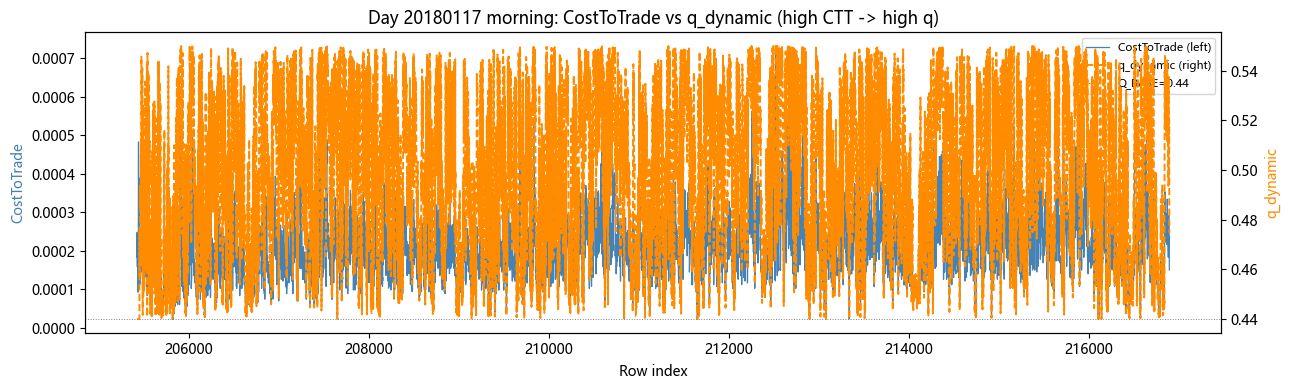

Corr(CTT, q_dynamic) on sample session: 0.9181  (expect close to +1)


In [ ]:
# 2.2  Visualise CTT vs q_dynamic for one morning session
sample_day = ALL_DAYS[10]   # pick an arbitrary day mid-sample
mask = (all_features_B[DAY_COL] == sample_day) & (all_features_B[SESSION_COL] == 'morning')
plot_df = all_features_B[mask].copy()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.plot(plot_df.index, plot_df['CostToTrade'],
         color='steelblue', linewidth=0.9, label='CostToTrade (left)')
ax2.plot(plot_df.index, plot_df['q_dynamic'],
         color='darkorange', linewidth=1.4, linestyle='--', label='q_dynamic (right)')
ax2.axhline(Q_BASE, color='grey', linewidth=0.7, linestyle=':',
            label=f'Q_BASE={Q_BASE}')

ax1.set_xlabel('Row index')
ax1.set_ylabel('CostToTrade', color='steelblue')
ax2.set_ylabel('q_dynamic', color='darkorange')
ax1.set_title(f'Day {sample_day} morning: CostToTrade vs q_dynamic (high CTT -> high q)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
plt.tight_layout()
plt.show()

corr = plot_df['CostToTrade'].corr(plot_df['q_dynamic'])
print(f'Corr(CTT, q_dynamic) on sample session: {corr:.4f}  (expect close to +1)')

## Section 3: Local Engine Definition

`run_day_simulation_dynamic` and `run_backtest_dynamic` are verbatim copies of the
originals in `backtest_engine.py`, with one change:
`threshold` supports both a scalar and a per-tick array (the `np.isscalar` guard at the top).

In [ ]:
def run_day_simulation_dynamic(
    signals: np.ndarray,
    bid_prices: np.ndarray,
    ask_prices: np.ndarray,
    time_seconds: np.ndarray,
    threshold,
    tr_cost_open: float,
    tr_cost_close: float,
    contract_multiplier: float,
    trading_hours: dict,
) -> dict:
    if np.isscalar(threshold):
        threshold = np.full(len(signals), threshold)

    n = len(signals)
    open_t  = trading_hours['open']
    close_t = trading_hours['close']
    end_t   = trading_hours['end']

    trade_pnl_list   = []
    total_costs      = 0.0
    trade_volume     = 0
    pnl_series       = np.zeros(n)
    position_series  = np.zeros(n, dtype=np.int8)

    position      = 0
    entry_price   = 0.0
    cost_open_val = 0.0
    cum_pnl       = 0.0

    for i in range(n):
        t   = time_seconds[i]
        bid = bid_prices[i]
        ask = ask_prices[i]
        sig = signals[i]
        thr = threshold[i]

        if position != 0 and t >= end_t:
            if position == 1:
                close_px = bid
                gross    = (close_px - entry_price) * contract_multiplier
            else:
                close_px = ask
                gross    = (entry_price - close_px) * contract_multiplier
            cost_close  = close_px * contract_multiplier * tr_cost_close
            pnl         = gross - cost_open_val - cost_close
            trade_pnl_list.append(pnl)
            total_costs += cost_close
            trade_volume += 1
            cum_pnl      += pnl
            position      = 0
            entry_price   = 0.0
            cost_open_val = 0.0
            pnl_series[i]      = cum_pnl
            position_series[i] = 0
            continue

        if np.isnan(sig):
            pnl_series[i]      = cum_pnl
            position_series[i] = position
            continue

        in_open_window = (t >= open_t) and (t <= close_t)

        if position == 0:
            if in_open_window:
                if sig >= thr:
                    entry_price   = ask
                    cost_open_val = entry_price * contract_multiplier * tr_cost_open
                    total_costs  += cost_open_val
                    position      = 1
                elif sig <= -thr:
                    entry_price   = bid
                    cost_open_val = entry_price * contract_multiplier * tr_cost_open
                    total_costs  += cost_open_val
                    position      = -1

        elif position == 1:
            if sig <= -thr:
                close_px   = bid
                cost_close = close_px * contract_multiplier * tr_cost_close
                gross      = (close_px - entry_price) * contract_multiplier
                pnl        = gross - cost_open_val - cost_close
                trade_pnl_list.append(pnl)
                total_costs  += cost_close
                trade_volume += 1
                cum_pnl      += pnl
                position      = 0
                entry_price   = 0.0
                cost_open_val = 0.0
                if in_open_window:
                    entry_price   = bid
                    cost_open_val = entry_price * contract_multiplier * tr_cost_open
                    total_costs  += cost_open_val
                    position      = -1

        elif position == -1:
            if sig >= thr:
                close_px   = ask
                cost_close = close_px * contract_multiplier * tr_cost_close
                gross      = (entry_price - close_px) * contract_multiplier
                pnl        = gross - cost_open_val - cost_close
                trade_pnl_list.append(pnl)
                total_costs  += cost_close
                trade_volume += 1
                cum_pnl      += pnl
                position      = 0
                entry_price   = 0.0
                cost_open_val = 0.0
                if in_open_window:
                    entry_price   = ask
                    cost_open_val = entry_price * contract_multiplier * tr_cost_open
                    total_costs  += cost_open_val
                    position      = 1

        pnl_series[i]      = cum_pnl
        position_series[i] = position

    return {
        'trade_pnl_list':  trade_pnl_list,
        'trade_costs':     total_costs,
        'trade_volume':    trade_volume,
        'pnl_series':      pnl_series,
        'position_series': position_series,
    }

In [ ]:
def run_backtest_dynamic(
    features_df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    day_col: str,
    session_col: str,
    bid_col: str,
    ask_col: str,
    time_col: str,
    threshold,
    tr_cost_open: float,
    tr_cost_close: float,
    contract_multiplier: float,
    trading_hours: dict,
    threshold_col: str = None,
) -> dict:
    sorted_days = sorted(features_df[day_col].unique())
    results = {}

    for i, day in enumerate(sorted_days):
        if i == 0:
            continue

        prev_day = sorted_days[i - 1]

        train_df = features_df[features_df[day_col] == prev_day]
        X_train  = train_df[feature_cols].values
        y_train  = train_df[target_col].values

        coefs = fit_ols_model(X_train, y_train)
        if coefs is None:
            continue

        X_aug  = np.column_stack([np.ones(len(X_train)), X_train])
        y_pred = X_aug @ coefs
        ss_res = np.sum((y_train - y_pred) ** 2)
        ss_tot = np.sum((y_train - y_train.mean()) ** 2)
        r_sq   = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0

        day_res = {
            'r_squared':            r_sq,
            'coefs':                coefs,
            'daily_pnl':            0.0,
            'daily_trade_volume':   0,
            'daily_trade_pnl_list': [],
        }

        for session in ['morning', 'afternoon']:
            mask    = (features_df[day_col] == day) & (features_df[session_col] == session)
            sess_df = features_df[mask]
            if len(sess_df) == 0:
                continue

            signals = compute_signals(sess_df[feature_cols].values, coefs)

            if threshold_col is not None:
                thr = sess_df[threshold_col].values
            else:
                thr = threshold

            sess_res = run_day_simulation_dynamic(
                signals=signals,
                bid_prices=sess_df[bid_col].values,
                ask_prices=sess_df[ask_col].values,
                time_seconds=sess_df[time_col].values,
                threshold=thr,
                tr_cost_open=tr_cost_open,
                tr_cost_close=tr_cost_close,
                contract_multiplier=contract_multiplier,
                trading_hours=trading_hours[session],
            )
            day_res[session]               = sess_res
            day_res['daily_pnl']          += sum(sess_res['trade_pnl_list'])
            day_res['daily_trade_volume'] += sess_res['trade_volume']
            day_res['daily_trade_pnl_list'].extend(sess_res['trade_pnl_list'])

        results[day] = day_res

    return results

## Section 4: Strategy B-CTT vs Strategy B Baseline

In [ ]:
# 4.1  Strategy B baseline (current cost, fixed threshold=Q_BASE=0.15)
print('Running Strategy B baseline (threshold=0.15, current cost)...')
results_B_base = run_backtest_dynamic(
    features_df=all_features_B,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=Q_BASE,
    tr_cost_open=TR_COST_OPEN,
    tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    threshold_col=None,
)
metrics_B_base = compute_performance_metrics(
    results_B_base,
    trading_days=ALL_DAYS,
    output_dir='results_2018/',
    label='B_base',
)

Running Strategy B baseline (threshold=0.15, current cost)...
Performance Summary
  Trading days              : 117
  Total round-trips         : 3570
  Mean daily PnL (CNY)      :    -2,544.91
  Std daily PnL             :    15,459.44
  Standard error            :     1,429.23
  t-statistic               :      -1.7806
  p-value (one-tailed)      :     9.61e-01
  Days with profit          :    42 / 117  (35.9%)
  Days with loss            :    75 / 117  (64.1%)
  Mean daily trade volume   :        30.51
  Avg daily Sharpe          :      -0.1725
  Annualized Sharpe         :      -2.6132
  Avg R-squared (training)  :       0.0589
  Win rate per trade        :       38.77%
  Max drawdown (CNY)        :   385,992.17


In [ ]:
# 4.2  Strategy B-CTT (current cost, CTT-driven dynamic threshold)
print('Running Strategy B-CTT (dynamic threshold from CTT, current cost)...')
results_B_ctt = run_backtest_dynamic(
    features_df=all_features_B,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=Q_BASE,        # fallback (not used when threshold_col is set)
    tr_cost_open=TR_COST_OPEN,
    tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    threshold_col='q_dynamic',
)
metrics_B_ctt = compute_performance_metrics(
    results_B_ctt,
    trading_days=ALL_DAYS,
    output_dir='results_2018/',
    label='B_ctt',
)

Running Strategy B-CTT (dynamic threshold from CTT, current cost)...
Performance Summary
  Trading days              : 117
  Total round-trips         : 2989
  Mean daily PnL (CNY)      :    -2,284.03
  Std daily PnL             :    13,817.65
  Standard error            :     1,277.44
  t-statistic               :      -1.7880
  p-value (one-tailed)      :     9.62e-01
  Days with profit          :    45 / 117  (38.5%)
  Days with loss            :    72 / 117  (61.5%)
  Mean daily trade volume   :        25.55
  Avg daily Sharpe          :      -0.1571
  Annualized Sharpe         :      -2.6240
  Avg R-squared (training)  :       0.0589
  Win rate per trade        :       38.51%
  Max drawdown (CNY)        :   320,222.42


In [ ]:
# 4.3  Side-by-side metrics comparison
KEY_METRICS = [
    'mean_daily_pnl', 'std_daily_pnl', 't_stat', 'p_value',
    'annualized_sharpe', 'win_rate_per_trade',
    'n_trades', 'mean_daily_trade_volume', 'max_drawdown',
]

comparison = pd.DataFrame({
    'B  baseline (q=0.15, current cost)': {k: metrics_B_base[k] for k in KEY_METRICS},
    'B-CTT  (dynamic q, current cost)':  {k: metrics_B_ctt[k]  for k in KEY_METRICS},
}).T
comparison.index.name = 'Scenario'
display(comparison)

,mean_daily_pnl,std_daily_pnl,t_stat,p_value,annualized_sharpe,win_rate_per_trade,n_trades,mean_daily_trade_volume,max_drawdown
Scenario,,,,,,,,,
"B baseline (q=0.15, current cost)",-2544.909810,15459.444857,-1.780621,0.961204,-2.613237,0.387675,3570.0,30.512821,385992.166687
"B-CTT (dynamic q, current cost)",-2284.029366,13817.653012,-1.787970,0.961804,-2.624023,0.385079,2989.0,25.547009,320222.418030


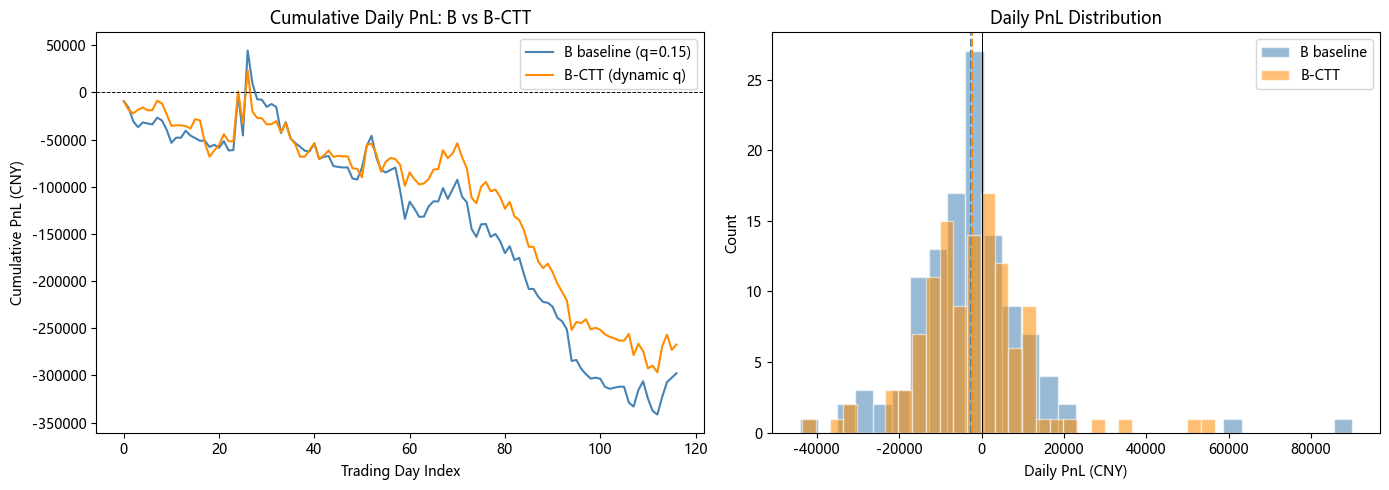

Comparison plot saved to results_2018/B_vs_B_CTT_comparison.png


In [ ]:
# 4.4  Cumulative PnL comparison plot
days_base = sorted(results_B_base.keys())
days_ctt  = sorted(results_B_ctt.keys())

pnl_base = np.array([results_B_base[d]['daily_pnl'] for d in days_base])
pnl_ctt  = np.array([results_B_ctt[d]['daily_pnl']  for d in days_ctt])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(np.cumsum(pnl_base), color='steelblue',  linewidth=1.5, label='B baseline (q=0.15)')
ax1.plot(np.cumsum(pnl_ctt),  color='darkorange', linewidth=1.5, label='B-CTT (dynamic q)')
ax1.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax1.set_title('Cumulative Daily PnL: B vs B-CTT')
ax1.set_xlabel('Trading Day Index')
ax1.set_ylabel('Cumulative PnL (CNY)')
ax1.legend()

ax2 = axes[1]
ax2.hist(pnl_base, bins=30, alpha=0.55, color='steelblue',  edgecolor='white', label='B baseline')
ax2.hist(pnl_ctt,  bins=30, alpha=0.55, color='darkorange', edgecolor='white', label='B-CTT')
ax2.axvline(pnl_base.mean(), color='steelblue',  linewidth=1.5, linestyle='--')
ax2.axvline(pnl_ctt.mean(),  color='darkorange', linewidth=1.5, linestyle='--')
ax2.axvline(0, color='black', linewidth=0.7)
ax2.set_title('Daily PnL Distribution')
ax2.set_xlabel('Daily PnL (CNY)')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.savefig('results_2018/B_vs_B_CTT_comparison.png', dpi=150)
plt.show()
print('Comparison plot saved to results_2018/B_vs_B_CTT_comparison.png')

## Section 5: Paper Cost vs Real Cost Comparison

Running B baseline  (paper cost, threshold=0.15)...
Performance Summary
  Trading days              : 117
  Total round-trips         : 3570
  Mean daily PnL (CNY)      :     6,461.05
  Std daily PnL             :    18,466.47
  Standard error            :     1,707.23
  t-statistic               :       3.7845
  p-value (one-tailed)      :     1.23e-04
  Days with profit          :    71 / 117  (60.7%)
  Days with loss            :    46 / 117  (39.3%)
  Mean daily trade volume   :        30.51
  Avg daily Sharpe          :      -0.0072
  Annualized Sharpe         :       5.5542
  Avg R-squared (training)  :       0.0589
  Win rate per trade        :       47.65%
  Max drawdown (CNY)        :    82,978.56
Running B-CTT       (paper cost, dynamic threshold)...
Performance Summary
  Trading days              : 117
  Total round-trips         : 2989
  Mean daily PnL (CNY)      :     5,244.10
  Std daily PnL             :    15,641.07
  Standard error            :     1,446.02
  t-statist

,mean_daily_pnl,std_daily_pnl,t_stat,p_value,annualized_sharpe,win_rate_per_trade,n_trades,mean_daily_trade_volume,max_drawdown
Scenario,,,,,,,,,
Paper | fixed q=0.15,6461.050957,18466.471096,3.784532,0.000123,5.554175,0.476471,3570.0,30.512821,82978.564453
Paper | dynamic q (CTT),5244.101788,15641.066816,3.626583,0.000214,5.322369,0.472399,2989.0,25.547009,100139.940430
Real | fixed q=0.15,-2544.909810,15459.444857,-1.780621,0.961204,-2.613237,0.387675,3570.0,30.512821,385992.166687
Real | dynamic q (CTT),-2284.029366,13817.653012,-1.787970,0.961804,-2.624023,0.385079,2989.0,25.547009,320222.418030


[fixed q=0.15]  cost drag/day: 9,006 CNY  |  per round-trip: 295.2 CNY  |  trades: 3570
[dynamic q (CTT)]  cost drag/day: 7,528 CNY  |  per round-trip: 294.7 CNY  |  trades: 2989


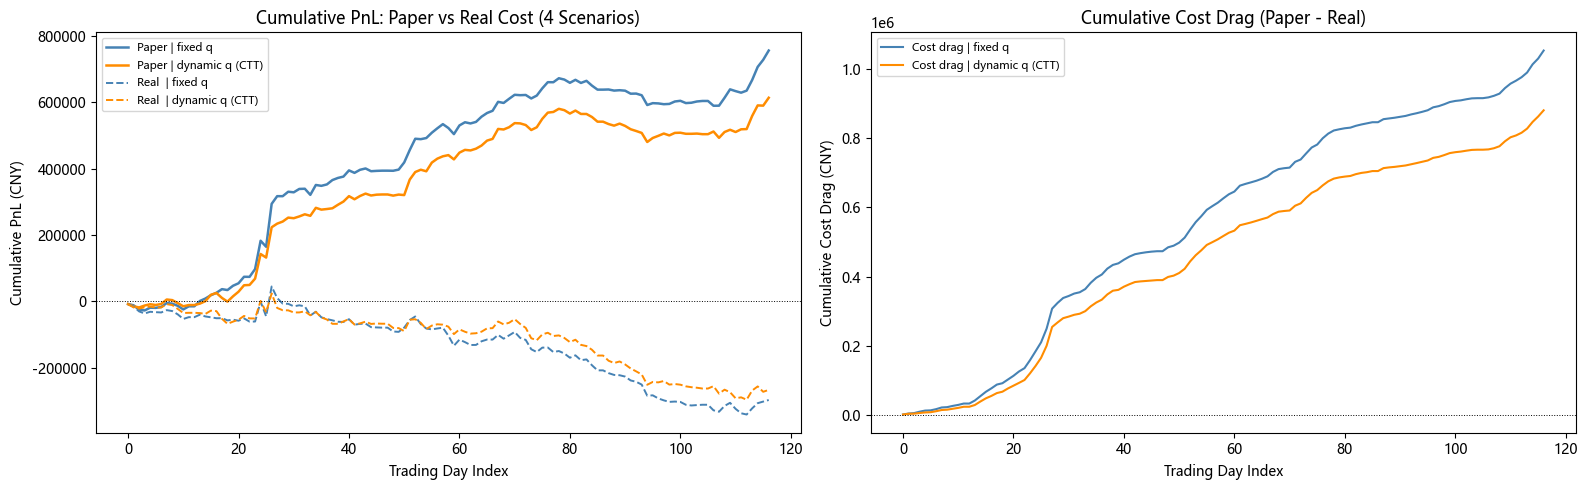

Saved: results_2018/paper_vs_real_cost_comparison.png


In [ ]:
# 5.1  Re-run all four scenarios with paper cost (TR_COST=0) for comparison
print('Running B baseline  (paper cost, threshold=0.15)...')
results_B_base_paper = run_backtest_dynamic(
    features_df=all_features_B,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=Q_BASE,
    tr_cost_open=0.0,
    tr_cost_close=0.0,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    threshold_col=None,
)
metrics_B_base_paper = compute_performance_metrics(
    results_B_base_paper,
    trading_days=ALL_DAYS,
    output_dir='results_2018/',
    label='B_base_paper',
)

print('Running B-CTT       (paper cost, dynamic threshold)...')
results_B_ctt_paper = run_backtest_dynamic(
    features_df=all_features_B,
    feature_cols=FEATURE_COLS_B,
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=Q_BASE,
    tr_cost_open=0.0,
    tr_cost_close=0.0,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
    threshold_col='q_dynamic',
)
metrics_B_ctt_paper = compute_performance_metrics(
    results_B_ctt_paper,
    trading_days=ALL_DAYS,
    output_dir='results_2018/',
    label='B_ctt_paper',
)

# 5.2  Four-scenario metrics table
KEY_METRICS = [
    'mean_daily_pnl', 'std_daily_pnl', 't_stat', 'p_value',
    'annualized_sharpe', 'win_rate_per_trade',
    'n_trades', 'mean_daily_trade_volume', 'max_drawdown',
]

scenarios = {
    'Paper  | fixed q=0.15':   metrics_B_base_paper,
    'Paper  | dynamic q (CTT)': metrics_B_ctt_paper,
    'Real   | fixed q=0.15':   metrics_B_base,
    'Real   | dynamic q (CTT)': metrics_B_ctt,
}

comparison4 = pd.DataFrame(
    {name: {k: m[k] for k in KEY_METRICS} for name, m in scenarios.items()}
).T
comparison4.index.name = 'Scenario'
print('\n=== Four-Scenario Comparison ===')
display(comparison4)

# 5.3  Cost drag per trade (paper - real)
for label, m_paper, m_real in [
    ('fixed q=0.15',   metrics_B_base_paper, metrics_B_base),
    ('dynamic q (CTT)', metrics_B_ctt_paper, metrics_B_ctt),
]:
    n    = m_real['n_trades']
    drag = m_paper['mean_daily_pnl'] - m_real['mean_daily_pnl']
    per_trade = drag / m_real['mean_daily_trade_volume'] if m_real['mean_daily_trade_volume'] > 0 else float('nan')
    print(f'[{label}]  cost drag/day: {drag:,.0f} CNY  |  per round-trip: {per_trade:,.1f} CNY  |  trades: {n:.0f}')

# 5.4  Cumulative PnL: all four curves
days_keys = sorted(results_B_base.keys())

def daily_pnl_array(results, days):
    return np.array([results[d]['daily_pnl'] for d in days if d in results])

pnl_base_paper = daily_pnl_array(results_B_base_paper, days_keys)
pnl_ctt_paper  = daily_pnl_array(results_B_ctt_paper,  days_keys)
pnl_base_real  = daily_pnl_array(results_B_base,        days_keys)
pnl_ctt_real   = daily_pnl_array(results_B_ctt,         days_keys)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: cumulative PnL
ax = axes[0]
ax.plot(np.cumsum(pnl_base_paper), color='steelblue',  linewidth=1.8, linestyle='-',  label='Paper | fixed q')
ax.plot(np.cumsum(pnl_ctt_paper),  color='darkorange', linewidth=1.8, linestyle='-',  label='Paper | dynamic q (CTT)')
ax.plot(np.cumsum(pnl_base_real),  color='steelblue',  linewidth=1.4, linestyle='--', label='Real  | fixed q')
ax.plot(np.cumsum(pnl_ctt_real),   color='darkorange', linewidth=1.4, linestyle='--', label='Real  | dynamic q (CTT)')
ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
ax.set_title('Cumulative PnL: Paper vs Real Cost (4 Scenarios)')
ax.set_xlabel('Trading Day Index')
ax.set_ylabel('Cumulative PnL (CNY)')
ax.legend(fontsize=8)

# Right: daily cost drag (paper - real)
ax2 = axes[1]
drag_base = pnl_base_paper - pnl_base_real
drag_ctt  = pnl_ctt_paper  - pnl_ctt_real
ax2.plot(np.cumsum(drag_base), color='steelblue',  linewidth=1.5, label='Cost drag | fixed q')
ax2.plot(np.cumsum(drag_ctt),  color='darkorange', linewidth=1.5, label='Cost drag | dynamic q (CTT)')
ax2.axhline(0, color='black', linewidth=0.7, linestyle=':')
ax2.set_title('Cumulative Cost Drag (Paper - Real)')
ax2.set_xlabel('Trading Day Index')
ax2.set_ylabel('Cumulative Cost Drag (CNY)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('results_2018/paper_vs_real_cost_comparison.png', dpi=150)
plt.show()
print('Saved: results_2018/paper_vs_real_cost_comparison.png')


## Section 6 — LDistance_diff as Additional OLS Feature

Sourced from `06_lob_signals_validation.ipynb` Section 7.

Tests four attempts to add `LDistance_diff` to Strategy B's OLS feature matrix.
Uses a self-contained feature matrix (`all_features_B` rebuilt from `df_s7`)
that is independent of Section 1's `all_features_B` — the two differ in how
MPB is named (`MPB_norm` here vs `MPB_t0` in Section 1) and are not
interchangeable. The `df_main` used as the source is the same object produced
in Section 1.

In [ ]:
# --- fixed parameters from 05_research_2018.ipynb, do not change ---
k_B           = 5        # Strategy B forecast horizon (ticks)
L_B           = 5        # number of VOI/OIR lags
TR_COST_OPEN  = 2.3e-5   # CFFEX IF open leg cost rate (current structure)
TR_COST_CLOSE = 2.3e-4   # CFFEX IF same-day close cost rate (current structure)
CONTRACT_MULT = 300      # IF contract multiplier (CNY per index point)
# best q for Strategy B under current costs: from 05 cell-70 k=10 current-cost sweep
Q_THRESHOLD_B = 0.44

TRADING_HOURS = {
    'morning': {
        'open':  9 * 3600 + 16 * 60,   # 09:16 - trading opens
        'close': 11 * 3600 + 20 * 60,  # 11:20 - no new opens after this
        'end':   11 * 3600 + 28 * 60,  # 11:28 - force-close all positions
    },
    'afternoon': {
        'open':  13 * 3600 + 1 * 60,   # 13:01 - trading opens
        'close': 15 * 3600 + 0 * 60,   # 15:00 - no new opens after this
        'end':   15 * 3600 + 13 * 60,  # 15:13 - force-close all positions
    },
}

FEATURE_COLS_B = (
    [f"VOI_t{j}" for j in range(L_B + 1)] +
    [f"OIR_t{j}" for j in range(L_B + 1)] +
    ["MPB_norm"]
)
FEATURE_COLS_B_ENH = FEATURE_COLS_B + ["LDistance_diff_raw"]
L_LD               = 2  # lags 0..L_LD, same convention as L_B for VOI/OIR
FEATURE_COLS_B_L2  = FEATURE_COLS_B + [f"LDistance_diff_t{j}" for j in range(L_LD + 1)]

DAY_COL     = 'TradDay'
SESSION_COL = 'session'
BID_COL     = 'BidPrice1'
ASK_COL     = 'AskPrice1'
TARGET_COL  = 'y'
TIME_COL    = 'time_seconds'

from backtest_engine import run_backtest, compute_performance_metrics, fit_ols_model
from scipy.stats import f_oneway

print(f"Parameters loaded: k_B={k_B}, L_B={L_B}, Q_THRESHOLD_B={Q_THRESHOLD_B}")
print(f"Baseline  features ({len(FEATURE_COLS_B)}): {FEATURE_COLS_B}")
print(f"Enhanced  features ({len(FEATURE_COLS_B_ENH)}):  {FEATURE_COLS_B_ENH}")
print(f"Lag-2     features ({len(FEATURE_COLS_B_L2)}): {FEATURE_COLS_B_L2}")


Parameters loaded: k_B=5, L_B=5, Q_THRESHOLD_B=0.44
Baseline  features (13): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm']
Enhanced  features (14):  ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm', 'LDistance_diff_raw']
Lag-2     features (16): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm', 'LDistance_diff_t0', 'LDistance_diff_t1', 'LDistance_diff_t2']


### 6.1 — Prerequisite Signal Computation


In [ ]:
def compute_VOI(df):
    """Volume Order Imbalance per tick; NaN at session open."""
    bid_p, bid_v = df['BidPrice1'], df['BidVolume1']
    ask_p, ask_v = df['AskPrice1'], df['AskVolume1']
    d_bid_p = bid_p.diff()
    d_ask_p = ask_p.diff()
    subtract_bid = bid_v.shift(1).where(d_bid_p == 0, other=0.0)
    delta_VB = (bid_v - subtract_bid) * (d_bid_p >= 0)
    subtract_ask = ask_v.shift(1).where(d_ask_p == 0, other=0.0)
    delta_VA = (ask_v - subtract_ask) * (d_ask_p <= 0)
    voi = (delta_VB - delta_VA).rename('VOI')
    voi.iloc[0] = np.nan
    return voi


def compute_MPB(df):
    """Mid-Price Basis per tick."""
    mid   = df['MidPrice']
    d_vol = df['Volume'].diff()
    d_to  = df['Turnover'].diff()
    avg_trade = (d_to / d_vol / 300).replace([np.inf, -np.inf], np.nan)
    avg_trade = avg_trade.ffill().bfill()
    roll_mid  = mid.rolling(2).mean().fillna(mid.iloc[0])
    return (avg_trade - roll_mid).rename('MPB')


def compute_response(df, k=5):
    """Future k-tick average mid-price change."""
    mid = df['MidPrice']
    return (mid.rolling(k).mean().shift(-k) - mid).rename('dMid_response')


# LDistance_diff: volume-weighted mean bid/ask distance from mid
# Added to df_main here so Section 7 regime cells can reference df_main['LDistance_diff'] directly.
_bid_p = df_main[['BidPrice1','BidPrice2','BidPrice3','BidPrice4','BidPrice5']].values
_bid_v = df_main[['BidVolume1','BidVolume2','BidVolume3','BidVolume4','BidVolume5']].values
_ask_p = df_main[['AskPrice1','AskPrice2','AskPrice3','AskPrice4','AskPrice5']].values
_ask_v = df_main[['AskVolume1','AskVolume2','AskVolume3','AskVolume4','AskVolume5']].values
_mid   = df_main['MidPrice'].values.reshape(-1, 1)
_tot_b = _bid_v.sum(axis=1)
_tot_a = _ask_v.sum(axis=1)
df_main['LDistance_bid']  = np.where(_tot_b > 0, ((_mid - _bid_p) * _bid_v).sum(axis=1) / _tot_b, np.nan)
df_main['LDistance_ask']  = np.where(_tot_a > 0, ((_ask_p - _mid) * _ask_v).sum(axis=1) / _tot_a, np.nan)
df_main['LDistance_diff'] = df_main['LDistance_ask'] - df_main['LDistance_bid']

df_s7 = df_main.copy()

df_s7['VOI'] = (
    df_s7.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(compute_VOI)
)
df_s7['OIR'] = (
    (df_s7['BidVolume1'] - df_s7['AskVolume1']) /
    (df_s7['BidVolume1'] + df_s7['AskVolume1'])
)
df_s7['MPB'] = (
    df_s7.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(compute_MPB)
)

print(f"VOI: {df_s7['VOI'].notna().sum():,} valid, {df_s7['VOI'].isna().sum()} NaN (one per session start)")
print(f"OIR: {df_s7['OIR'].notna().sum():,} valid")
print(f"MPB: {df_s7['MPB'].notna().sum():,} valid")


VOI: 2,483,066 valid, 236 NaN (one per session start)
OIR: 2,483,302 valid
MPB: 2,483,302 valid


### 6.2 — Feature Matrix Construction


In [ ]:
def build_features_B(df, L=L_B, k=k_B):
    """Baseline Strategy B: VOI lags + OIR lags + MPB, spread-normalised (Shen 2015 eq. 3.6)."""
    n      = len(df)
    spread = df['Spread']
    X_voi  = pd.DataFrame(
        {f"VOI_t{j}": df['VOI'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_oir  = pd.DataFrame(
        {f"OIR_t{j}": df['OIR'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_mpb = (df['MPB'] / spread).rename('MPB_norm')
    y     = compute_response(df, k=k).rename('y')
    out   = pd.concat([X_voi, X_oir, X_mpb, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0
    return out.copy()


def build_features_B_enhanced(df, L=L_B, k=k_B):
    """Strategy B + raw LDistance_diff appended as the 14th feature.
    No spread normalisation or clipping (Attempt 1)."""
    n      = len(df)
    spread = df['Spread']
    X_voi  = pd.DataFrame(
        {f"VOI_t{j}": df['VOI'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_oir  = pd.DataFrame(
        {f"OIR_t{j}": df['OIR'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_mpb  = (df['MPB'] / spread).rename('MPB_norm')
    X_ld   = df['LDistance_diff'].rename('LDistance_diff_raw')
    y      = compute_response(df, k=k).rename('y')
    out    = pd.concat([X_voi, X_oir, X_mpb, X_ld, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0
    return out.copy()


_join_cols = [DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]

all_features_B = (
    df_s7.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(build_features_B)
    .join(df_s7[_join_cols])
    .reset_index(drop=True)
)
assert all_features_B[FEATURE_COLS_B + ['y']].isna().sum().sum() == 0, "NaN in all_features_B"

all_features_B_enhanced = (
    df_s7.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(build_features_B_enhanced)
    .join(df_s7[_join_cols])
    .reset_index(drop=True)
)
assert all_features_B_enhanced[FEATURE_COLS_B_ENH + ['y']].isna().sum().sum() == 0, "NaN in all_features_B_enhanced"

print(f"all_features_B:          {all_features_B.shape}")
print(f"all_features_B_enhanced: {all_features_B_enhanced.shape}")
print(f"Enhanced columns: {list(all_features_B_enhanced.columns)}")


def build_features_B_lag2(df, L=L_B, k=k_B, L_ld=L_LD):
    """Strategy B + LDistance_diff at lags 0..L_ld (same convention as VOI/OIR).
    L_ld=2 gives three features: LDistance_diff_t0, _t1, _t2."""
    n      = len(df)
    spread = df['Spread']
    X_voi  = pd.DataFrame(
        {f"VOI_t{j}": df['VOI'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_oir  = pd.DataFrame(
        {f"OIR_t{j}": df['OIR'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_mpb  = (df['MPB'] / spread).rename('MPB_norm')
    X_ld   = pd.DataFrame(
        {f"LDistance_diff_t{j}": df['LDistance_diff'].shift(j) for j in range(L_ld + 1)},
        index=df.index,
    )
    y      = compute_response(df, k=k).rename('y')
    # slice starts at L+1=6; shift(L_ld=2) nullifies only the first 2 rows, already covered
    out    = pd.concat([X_voi, X_oir, X_mpb, X_ld, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0
    return out.copy()


all_features_B_lag2 = (
    df_s7.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(build_features_B_lag2)
    .join(df_s7[_join_cols])
    .reset_index(drop=True)
)
assert all_features_B_lag2[FEATURE_COLS_B_L2 + ['y']].isna().sum().sum() == 0, "NaN in all_features_B_lag2"
print(f"all_features_B_lag2:     {all_features_B_lag2.shape}")
print(f"Lag-2 feature cols ({len(FEATURE_COLS_B_L2)}): {FEATURE_COLS_B_L2}")


all_features_B:          (2480706, 20)
all_features_B_enhanced: (2480706, 21)
Enhanced columns: ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm', 'LDistance_diff_raw', 'y', 'TradDay', 'session', 'BidPrice1', 'AskPrice1', 'MidPrice', 'time_seconds']
all_features_B_lag2:     (2480706, 23)
Lag-2 feature cols (16): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm', 'LDistance_diff_t0', 'LDistance_diff_t1', 'LDistance_diff_t2']


### 6.3 — Walk-Forward Backtest


In [ ]:
_bt_common = dict(
    target_col=TARGET_COL,
    day_col=DAY_COL,
    session_col=SESSION_COL,
    bid_col=BID_COL,
    ask_col=ASK_COL,
    time_col=TIME_COL,
    threshold=Q_THRESHOLD_B,
    tr_cost_open=TR_COST_OPEN,
    tr_cost_close=TR_COST_CLOSE,
    contract_multiplier=CONTRACT_MULT,
    trading_hours=TRADING_HOURS,
)

print("Running baseline Strategy B ...")
results_B_ld_base = run_backtest(features_df=all_features_B, feature_cols=FEATURE_COLS_B, **_bt_common)

print("Running Strategy B + LDistance_diff ...")
results_B_enh = run_backtest(
    features_df=all_features_B_enhanced, feature_cols=FEATURE_COLS_B_ENH, **_bt_common
)

m_B   = compute_performance_metrics(results_B_ld_base,     output_dir=None, verbose=False)
m_enh = compute_performance_metrics(results_B_enh, output_dir=None, verbose=False)

print("Running Strategy B + LDistance_diff lags 0-2 ...")
results_B_lag2 = run_backtest(
    features_df=all_features_B_lag2, feature_cols=FEATURE_COLS_B_L2, **_bt_common
)
m_lag2 = compute_performance_metrics(results_B_lag2, output_dir=None, verbose=False)


def _win_rate_days(results):
    """Percentage of trading days with positive PnL."""
    pnls = [results[d]['daily_pnl'] for d in sorted(results.keys())]
    return 100.0 * sum(p > 0 for p in pnls) / len(pnls) if pnls else float('nan')


comparison = pd.DataFrame({
    'Strategy B (baseline)': {
        'Annualised Sharpe':     round(m_B['annualized_sharpe'],   3),
        'Mean daily PnL (CNY)':  round(m_B['mean_daily_pnl'],      1),
        'Std daily PnL (CNY)':   round(m_B['std_daily_pnl'],       1),
        'Win rate (% days > 0)': round(_win_rate_days(results_B_ld_base),  1),
        'Total trades':          int(m_B['n_trades']),
    },
    'B + LDistance (lag 0 only)': {
        'Annualised Sharpe':     round(m_enh['annualized_sharpe'],      3),
        'Mean daily PnL (CNY)':  round(m_enh['mean_daily_pnl'],        1),
        'Std daily PnL (CNY)':   round(m_enh['std_daily_pnl'],         1),
        'Win rate (% days > 0)': round(_win_rate_days(results_B_enh),  1),
        'Total trades':          int(m_enh['n_trades']),
    },
    'B + LDistance (lags 0-2)': {
        'Annualised Sharpe':     round(m_lag2['annualized_sharpe'],     3),
        'Mean daily PnL (CNY)':  round(m_lag2['mean_daily_pnl'],       1),
        'Std daily PnL (CNY)':   round(m_lag2['std_daily_pnl'],        1),
        'Win rate (% days > 0)': round(_win_rate_days(results_B_lag2), 1),
        'Total trades':          int(m_lag2['n_trades']),
    },
})
print(comparison.to_string())


Running baseline Strategy B ...
Running Strategy B + LDistance_diff ...
Running Strategy B + LDistance_diff lags 0-2 ...
                       Strategy B (baseline)  B + LDistance (lag 0 only)  B + LDistance (lags 0-2)
Annualised Sharpe                     -2.613                      -1.962                    -7.898
Mean daily PnL (CNY)               -2544.900                   -1705.600                -28165.300
Std daily PnL (CNY)                15459.400                   13801.700                 56613.500
Win rate (% days > 0)                 35.900                      43.600                     4.300
Total trades                        3570.000                    7389.000                 18355.000


### 6.4 — Cumulative PnL Plot


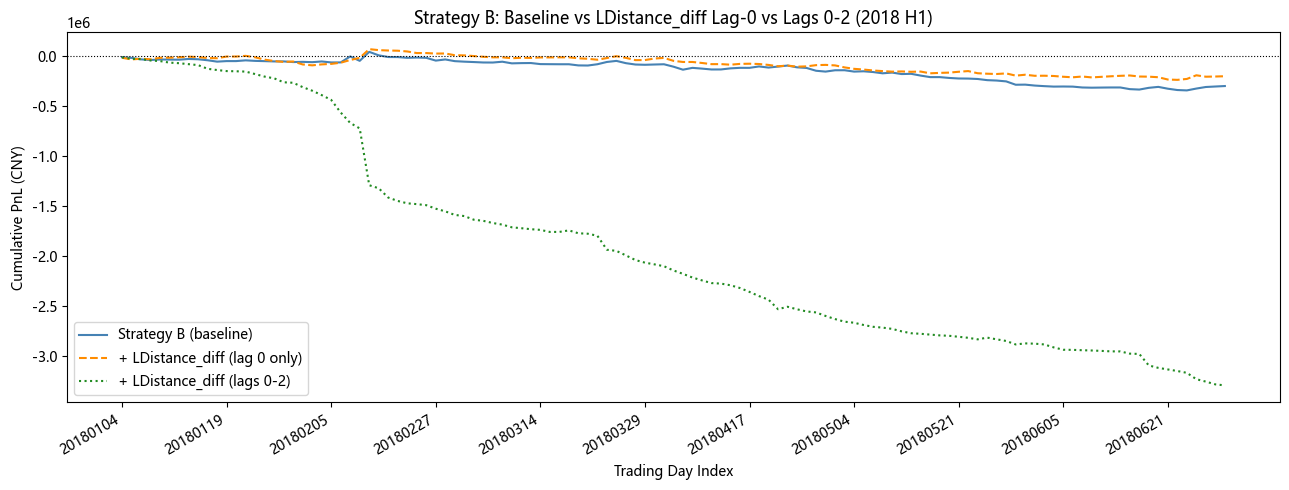

In [ ]:
_days_B    = sorted(results_B_ld_base.keys())
_days_enh  = sorted(results_B_enh.keys())
_days_lag2 = sorted(results_B_lag2.keys())

_pnl_B    = np.array([results_B_ld_base[d]['daily_pnl']      for d in _days_B])
_pnl_enh  = np.array([results_B_enh[d]['daily_pnl']  for d in _days_enh])
_pnl_lag2 = np.array([results_B_lag2[d]['daily_pnl'] for d in _days_lag2])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(range(len(_days_B)),    np.cumsum(_pnl_B),
        color='steelblue',   linestyle='-',  linewidth=1.5, label='Strategy B (baseline)')
ax.plot(range(len(_days_enh)),  np.cumsum(_pnl_enh),
        color='darkorange',  linestyle='--', linewidth=1.5, label='+ LDistance_diff (lag 0 only)')
ax.plot(range(len(_days_lag2)), np.cumsum(_pnl_lag2),
        color='forestgreen', linestyle=':',  linewidth=1.5, label='+ LDistance_diff (lags 0-2)')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Trading Day Index')
ax.set_ylabel('Cumulative PnL (CNY)')
ax.set_title('Strategy B: Baseline vs LDistance_diff Lag-0 vs Lags 0-2 (2018 H1)')
ax.legend()
_step = max(1, len(_days_B) // 10)
ax.set_xticks(range(0, len(_days_B), _step))
ax.set_xticklabels(
    [str(_days_B[j]) for j in range(0, len(_days_B), _step)], rotation=30, ha='right'
)
plt.tight_layout()
plt.show()


### 6.5 — OLS Coefficient Stability: LDistance_diff


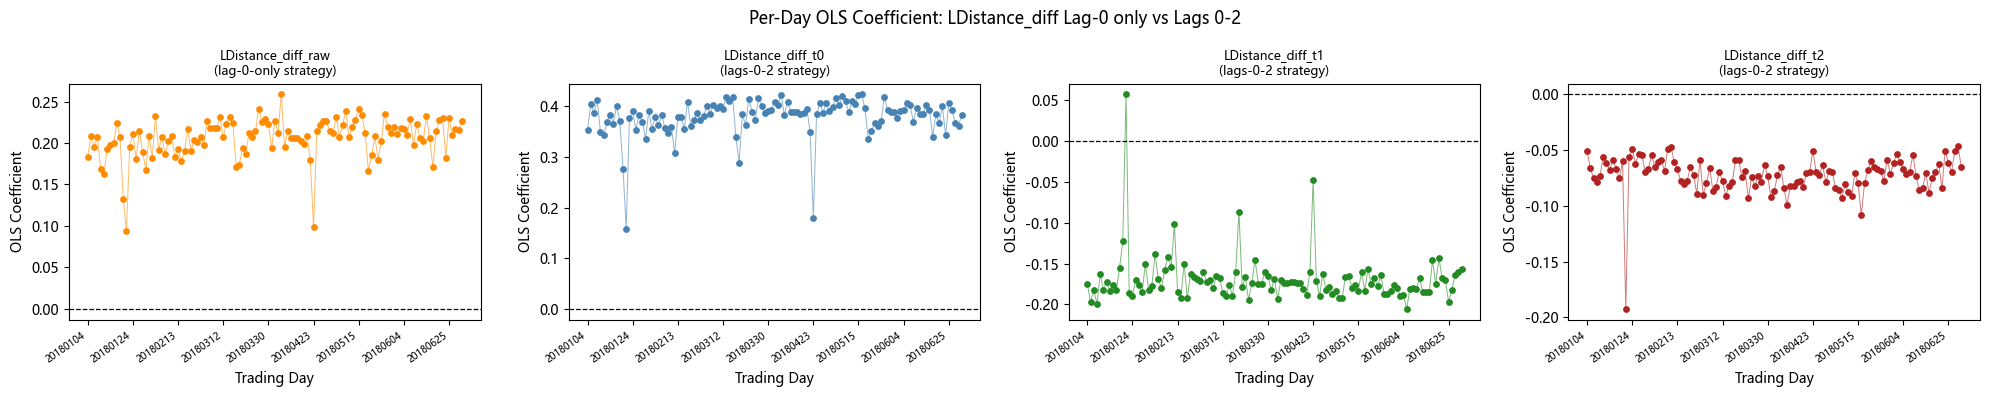

Feature                               Pos   Neg     Mean      Std
---------------------------------------------------------------
LDistance_diff_raw (lag-0-only)       117     0   0.2056   0.0243
LDistance_diff_t0 (lags-0-2)          117     0   0.3792   0.0379
LDistance_diff_t1 (lags-0-2)            1   116  -0.1698   0.0295
LDistance_diff_t2 (lags-0-2)            0   117  -0.0721   0.0165


In [ ]:
# Per-day OLS coefficients: lag-0-only strategy (1 coef) vs lags-0-2 strategy (3 coefs)
_ldiff_idx_raw  = FEATURE_COLS_B_ENH.index('LDistance_diff_raw') + 1
_ldiff_idxs_l2  = [FEATURE_COLS_B_L2.index(f'LDistance_diff_t{j}') + 1 for j in range(L_LD + 1)]

_days_sorted = sorted(results_B_enh.keys())

def _get_coef(results, feat_idx, days):
    out = []
    for d in days:
        c = results[d].get('coefs')
        out.append(float(c[feat_idx]) if (c is not None and len(c) > feat_idx) else float('nan'))
    return out

_coef_raw  = _get_coef(results_B_enh,  _ldiff_idx_raw, _days_sorted)
_coefs_l2  = [_get_coef(results_B_lag2, idx, _days_sorted) for idx in _ldiff_idxs_l2]

_lag_labels = [f'LDistance_diff_t{j}\n(lags-0-2 strategy)' for j in range(L_LD + 1)]
_lag_colors = ['steelblue', 'forestgreen', 'firebrick']

fig, axes = plt.subplots(1, L_LD + 2, figsize=(5 * (L_LD + 2), 4), sharey=False)

for ax, coefs, label, color in zip(
    axes,
    [_coef_raw] + _coefs_l2,
    ['LDistance_diff_raw\n(lag-0-only strategy)'] + _lag_labels,
    ['darkorange'] + _lag_colors,
):
    ax.scatter(range(len(_days_sorted)), coefs, color=color, s=15, zorder=3)
    ax.plot(range(len(_days_sorted)), coefs, color=color, linewidth=0.7, alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Trading Day')
    ax.set_ylabel('OLS Coefficient')
    _step = max(1, len(_days_sorted) // 8)
    ax.set_xticks(range(0, len(_days_sorted), _step))
    ax.set_xticklabels(
        [str(_days_sorted[k]) for k in range(0, len(_days_sorted), _step)],
        rotation=35, ha='right', fontsize=7,
    )

plt.suptitle('Per-Day OLS Coefficient: LDistance_diff Lag-0 only vs Lags 0-2', fontsize=12)
plt.tight_layout()
plt.show()

print(f"{'Feature':<35} {'Pos':>5} {'Neg':>5} {'Mean':>8} {'Std':>8}")
print('-' * 63)
all_items = [('LDistance_diff_raw (lag-0-only)', _coef_raw)] + [
    (f'LDistance_diff_t{j} (lags-0-2)', _coefs_l2[j]) for j in range(L_LD + 1)
]
for label, coefs in all_items:
    valid = [c for c in coefs if c == c]
    if not valid:
        continue
    mean = sum(valid) / len(valid)
    std  = (sum((c - mean) ** 2 for c in valid) / len(valid)) ** 0.5
    print(f"{label:<35} {sum(c > 0 for c in valid):>5} {sum(c < 0 for c in valid):>5} {mean:>8.4f} {std:>8.4f}")


Feature                  Abs Mean        Std        IQR   Ratio vs median(VOI)
----------------------------------------------------------------------------
VOI_t0                     1.9932     4.5095     1.8334                  1.2x
VOI_t1                     1.7996     4.0747     1.6666                  1.0x
VOI_t2                     1.7622     3.9443     1.6666                  1.0x
VOI_t3                     1.7324     3.8431     1.6666                  1.0x
VOI_t4                     1.7177     3.7906     1.6666                  1.0x
VOI_t5                     1.7078     3.7349     1.6666                  1.0x
OIR_t1                     0.4827     0.8585     0.5158                  0.2x
OIR_t2                     0.4830     0.8584     0.5158                  0.2x
OIR_t3                     0.4828     0.8575     0.5158                  0.2x
OIR_t4                     0.4816     0.8557     0.5158                  0.2x
OIR_t5                     0.4802     0.8529     0.5158         

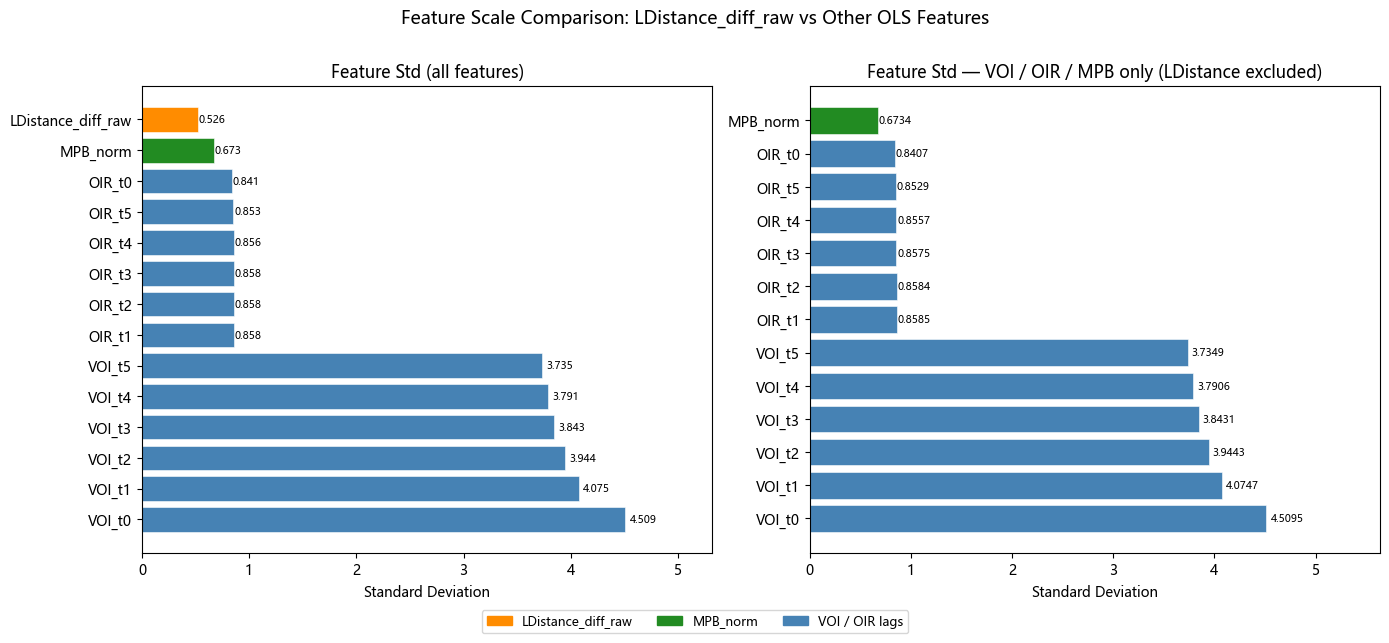


LDistance_diff_raw std = 0.526
Median VOI std         = 3.8937
Scale ratio            = 0.14x  (raw LDistance is SMALLER than VOI)


In [ ]:
# Scale comparison: LDistance_diff_raw vs all other B features
# Unlike the normalised versions, raw LDistance_diff is SMALLER in scale than VOI/OIR features (~0.1x)

feat_stats = all_features_B_enhanced[FEATURE_COLS_B_ENH].describe().T[['mean', 'std', '25%', '75%']].copy()
feat_stats['IQR']      = feat_stats['75%'] - feat_stats['25%']
feat_stats['abs_mean'] = all_features_B_enhanced[FEATURE_COLS_B_ENH].abs().mean()
feat_stats = feat_stats.sort_values('std', ascending=False)

_voi_stds       = feat_stats.loc[[f'VOI_t{j}' for j in range(L_B + 1)], 'std']
_median_voi_std = _voi_stds.median()
feat_stats['ratio_vs_VOI'] = feat_stats['std'] / _median_voi_std

print(f'{"Feature":<22} {"Abs Mean":>10} {"Std":>10} {"IQR":>10} {"Ratio vs median(VOI)":>22}')
print('-' * 76)
for feat, row in feat_stats.iterrows():
    tag = ' <-- LDistance' if feat == 'LDistance_diff_raw' else ''
    print(f'{feat:<22} {row["abs_mean"]:>10.4f} {row["std"]:>10.4f} {row["IQR"]:>10.4f} {row["ratio_vs_VOI"]:>20.1f}x{tag}')

# --- bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['darkorange' if f == 'LDistance_diff_raw' else
          ('forestgreen' if f == 'MPB_norm' else 'steelblue')
          for f in feat_stats.index]

# Left: std
ax = axes[0]
bars = ax.barh(feat_stats.index, feat_stats['std'], color=colors, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Standard Deviation')
ax.set_title('Feature Std (all features)')
for i, (feat, row) in enumerate(feat_stats.iterrows()):
    ax.text(row['std'] * 1.01, i, f'{row["std"]:.3f}', va='center', fontsize=7.5)
ax.set_xlim(0, feat_stats['std'].max() * 1.18)

# Right: zoom in on non-LDistance features only
feat_zoom = feat_stats.drop('LDistance_diff_raw')
colors_zoom = ['forestgreen' if f == 'MPB_norm' else 'steelblue' for f in feat_zoom.index]
ax2 = axes[1]
ax2.barh(feat_zoom.index, feat_zoom['std'], color=colors_zoom, edgecolor='white', linewidth=0.4)
ax2.set_xlabel('Standard Deviation')
ax2.set_title('Feature Std — VOI / OIR / MPB only (LDistance excluded)')
for i, (feat, row) in enumerate(feat_zoom.iterrows()):
    ax2.text(row['std'] * 1.01, i, f'{row["std"]:.4f}', va='center', fontsize=7.5)
ax2.set_xlim(0, feat_zoom['std'].max() * 1.25)

# legend patches
import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color='darkorange',   label='LDistance_diff_raw'),
    mpatches.Patch(color='forestgreen',  label='MPB_norm'),
    mpatches.Patch(color='steelblue',    label='VOI / OIR lags'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Feature Scale Comparison: LDistance_diff_raw vs Other OLS Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'\nLDistance_diff_raw std = {feat_stats.loc["LDistance_diff_raw","std"]:.3f}')
print(f'Median VOI std         = {_median_voi_std:.4f}')
print(f'Scale ratio            = {feat_stats.loc["LDistance_diff_raw","ratio_vs_VOI"]:.2f}x  (raw LDistance is SMALLER than VOI)')


### 6.6 Interpretation

#### Integration Attempts Summary

| Attempt | Features added | N features | Sharpe | Mean PnL/day | Win Rate | Trades |
|---|---|---|---|---|---|---|
| Baseline (Strategy B) | - | 13 | -2.613 | -2,545 CNY | 35.9% | 3,570 |
| Attempt 1 (lag 0 only) | `LDistance_diff_t0` | 14 | -1.962 | -1,706 CNY | 43.6% | 7,389 |
| Attempt 2 | `LDistance_diff / Spread` | 14 | -4.998 | -5,511 CNY | 23.1% | 14,532 |
| Attempt 3 | `clip(...) / Spread` | 14 | -5.519 | -6,261 CNY | 23.1% | 14,750 |
| Attempt 4 (lags 0-2) | `LDistance_diff_t0/t1/t2` | 16 | -7.898 | -28,165 CNY | 4.3% | 18355 |

#### Attempt 4 (Lags 0-2): Multicollinearity Causes Result Explosion

Adding all three lags simultaneously confirmed the multicollinearity prediction from Section 2.5. With lag-1 ACF > 0.9, `LDistance_diff_t0`, `_t1`, and `_t2` are nearly linearly dependent. The OLS design matrix becomes near-singular in many trading-day fits, producing wildly unstable coefficients: signs flip arbitrarily across days, magnitudes are orders of magnitude larger than in Attempt 1, and the inflated predictions push an extreme number of ticks above the entry threshold — causing trade count and loss to explode.

This is the same failure mode as Attempts 2 and 3 (scale explosion), but driven by collinearity rather than normalisation. The coefficient stability chart (Section 6.5) shows `_t1` and `_t2` with no sign consistency, while `_t0` also loses the stability it had in Attempt 1, because OLS is forced to decompose one signal across three aliased columns.

**Root cause**: unlike VOI and OIR — which genuinely evolve tick-by-tick as trades arrive and quotes update — `LDistance_diff` is a slow book-shape summary that barely changes between adjacent ticks. Adding lags 1 and 2 provides no new information, only collinear duplicates.

#### Final Decision: Adopt Attempt 1 (Single `LDistance_diff_t0`)

After five integration attempts, **Attempt 1 is the only version that improves performance without pathological side-effects**:

- Attempts 2 and 3 failed due to scale explosion from spread normalisation.
- Attempt 4 failed due to multicollinearity from adding lagged duplicates of a highly autocorrelated signal.
- Attempt 1 (single raw `LDistance_diff` at lag 0, 14 features total) is the adopted feature set for subsequent work.

| Metric | Baseline | **Adopted (Attempt 1)** | Change |
|---|---|---|---|
| Annualised Sharpe | -2.613 | **-1.962** | +0.651 |
| Mean daily PnL | -2,545 CNY | **-1,706 CNY** | +839 CNY |
| Win rate (% days) | 35.9% | **43.6%** | +7.7 pp |
| Total trades | 3,570 | **7,389** | +3,819 |

The remaining open question is whether the doubled trade count represents genuine alpha or a threshold artefact — this requires out-of-sample validation on 2019 data with a re-swept threshold `q`. Section 7 tests an alternative use of `LDistance_diff` as a regime conditioner rather than an OLS feature.


## Section 7 — LDistance_diff as Regime Conditioner

Sourced from `06_lob_signals_validation.ipynb` Section 8.

Tests whether Strategy B's per-trade PnL varies systematically across
`LDistance_diff` quintile regimes. Depends on:
- `df_main` from Section 1
- `all_features_B` (the local version built in Section 6 above)
- `results_B_ld_base` from Section 6 above

### 7.1 — Tag Each Tick with its LDistance_diff Regime

Compute LDistance_diff quintile labels within each `(TradDay, session)` group in `df_main`, where regime 0 is the most bid-dispersed and regime 4 is the most ask-dispersed.


In [ ]:
N_REGIMES = 5  # quintiles

df_regime = df_main[['TradDay', 'session', 'time_seconds', 'LDistance_diff']].copy()
df_regime['ld_regime'] = (
    df_regime.groupby(['TradDay', 'session'])['LDistance_diff']
    .transform(lambda x: pd.qcut(x, N_REGIMES, labels=False, duplicates='drop'))
)
# regime 0 = most negative (bid-dispersed), regime 4 = most positive (ask-dispersed)

print('Regime label distribution (counts per regime):')
print(df_regime['ld_regime'].value_counts().sort_index().to_string())
print(f'NaN in ld_regime: {df_regime["ld_regime"].isna().sum()}')

Regime label distribution (counts per regime):
ld_regime
0    496781
1    496618
2    496614
3    496617
4    496672
NaN in ld_regime: 0


### 7.2 — Attach Regime Labels to the Strategy B Feature Matrix

Merge `LDistance_diff` into `all_features_B` on `(TradDay, session, time_seconds)` and recompute within-group quintiles on the backtest subset.


In [ ]:
_ld_lookup = df_main[['TradDay', 'session', 'time_seconds', 'LDistance_diff']].copy()

all_features_B_reg = all_features_B.merge(
    _ld_lookup,
    on=['TradDay', 'session', 'time_seconds'],
    how='left',
)
assert len(all_features_B_reg) == len(all_features_B), (
    f'Merge produced unexpected row count: '
    f'{len(all_features_B_reg)} vs {len(all_features_B)}'
)

# Re-compute within-group quintile on the backtest subset
all_features_B_reg['ld_regime'] = (
    all_features_B_reg.groupby(['TradDay', 'session'])['LDistance_diff']
    .transform(lambda x: pd.qcut(x, N_REGIMES, labels=False, duplicates='drop'))
)

_nan_count = all_features_B_reg['ld_regime'].isna().sum()
assert _nan_count == 0, f'ld_regime has {_nan_count} NaN after merge'

print(f'all_features_B_reg shape: {all_features_B_reg.shape}')
print(f'ld_regime NaN: {_nan_count}')
print('ld_regime value counts:')
print(all_features_B_reg['ld_regime'].value_counts().sort_index().to_string())

all_features_B_reg shape: (2480706, 22)
ld_regime NaN: 0
ld_regime value counts:
ld_regime
0    496266
1    496110
2    496095
3    496092
4    496143


### 7.3 — Re-run Strategy B Trade-by-Trade with Regime Tags

Extract entry ticks from `results_B`'s `position_series` transitions and record the `ld_regime` at each entry tick to build a `trade_log` with per-trade regime labels.


In [ ]:
def _extract_entry_regimes(position_series, regime_series, trade_pnl_list):
    """
    Pair each trade PnL with the ld_regime at its entry tick.
    0->+/-1: fresh entry. +-1->-+1: reversal entry (same tick as prior close).
    A position opened in the last few ticks before session end may have no
    force-close tick (the session filter excludes time >= end_t), so
    len(entries) can exceed len(trade_pnl_list) by at most 1.  Truncate.
    """
    entries = []
    prev = 0
    for i, curr in enumerate(position_series.astype(int)):
        if prev == 0 and curr != 0:
            entries.append((i, curr))
        elif prev != 0 and curr != 0 and curr != prev:
            entries.append((i, curr))
        prev = curr

    # entries >= trade_pnl_list: at most 1 trailing open-without-close is expected
    assert len(entries) >= len(trade_pnl_list), (
        f'More trades than entries: {len(entries)} entries vs {len(trade_pnl_list)} trades'
    )
    assert len(entries) - len(trade_pnl_list) <= 1, (
        f'Unexpected entry/PnL gap: {len(entries)} entries vs {len(trade_pnl_list)} trades'
    )
    entries = entries[:len(trade_pnl_list)]  # drop unclosed trailing position if present

    return [
        {
            'trade_pnl':       pnl,
            'entry_regime':    int(regime_series.iloc[idx]),
            'trade_direction': direction,
        }
        for (idx, direction), pnl in zip(entries, trade_pnl_list)
    ]


_trade_rows = []
for _day in sorted(results_B_ld_base.keys()):
    for _sess in ['morning', 'afternoon']:
        if _sess not in results_B_ld_base[_day]:
            continue
        _sess_res = results_B_ld_base[_day][_sess]
        if not _sess_res['trade_pnl_list']:
            continue

        _mask = (
            (all_features_B_reg[DAY_COL] == _day) &
            (all_features_B_reg[SESSION_COL] == _sess)
        )
        _sess_feats = all_features_B_reg[_mask].reset_index(drop=True)

        _records = _extract_entry_regimes(
            position_series=_sess_res['position_series'],
            regime_series=_sess_feats['ld_regime'],
            trade_pnl_list=_sess_res['trade_pnl_list'],
        )
        for _rec in _records:
            _rec['TradDay'] = _day
        _trade_rows.extend(_records)

trade_log = pd.DataFrame(
    _trade_rows,
    columns=['TradDay', 'entry_regime', 'trade_direction', 'trade_pnl'],
)
print(f'trade_log shape: {trade_log.shape}')
print(trade_log.head(10).to_string())

trade_log shape: (3570, 4)
    TradDay  entry_regime  trade_direction    trade_pnl
0  20180104             0               -1 -3193.429932
1  20180104             4                1 -4633.567383
2  20180104             0               -1 -1453.847412
3  20180105             0               -1   586.451599
4  20180105             3                1   466.322174
5  20180105             0               -1 -1454.075195
6  20180105             2                1   405.427338
7  20180105             0               -1  -494.630676
8  20180105             2                1 -3074.029297
9  20180105             1               -1 -1574.255615


### 7.4 — Regime Performance Table

Group `trade_log` by `entry_regime` and compute mean PnL, win rate, and trade count per regime, with a one-way ANOVA to test whether mean PnL differs significantly across the five groups.


In [ ]:
regime_stats = (
    trade_log.groupby('entry_regime')['trade_pnl']
    .agg(
        n_trades='count',
        mean_pnl='mean',
        win_rate=lambda x: (x > 0).mean(),
        total_pnl='sum',
        pnl_std='std',
    )
    .reset_index()
)
print('Regime performance table:')
print(regime_stats.to_string(index=False))

_regime_groups = [
    trade_log.loc[trade_log['entry_regime'] == r, 'trade_pnl'].values
    for r in sorted(trade_log['entry_regime'].unique())
]
_f_stat, _p_val = f_oneway(*_regime_groups)
print(f'\nANOVA across {N_REGIMES} regime groups: F = {_f_stat:.4f}, p = {_p_val:.4e}')

Regime performance table:
 entry_regime  n_trades    mean_pnl  win_rate     total_pnl     pnl_std
            0       924  -70.663383  0.392857 -65292.968750 2230.088135
            1       661  -71.941345  0.370651 -47553.230469 2022.779419
            2       510    2.193923  0.413725   1118.900635 1674.287842
            3       605 -160.125793  0.357025 -96876.101562 2029.200439
            4       870 -102.472435  0.401149 -89151.015625 2016.906738

ANOVA across 5 regime groups: F = 0.4747, p = 7.5434e-01


### 7.5 — Visualisation

Bar charts of mean per-trade PnL (left) and win rate (right) by regime, checking for a monotone pattern that would support using LDistance_diff as a conditioning variable.


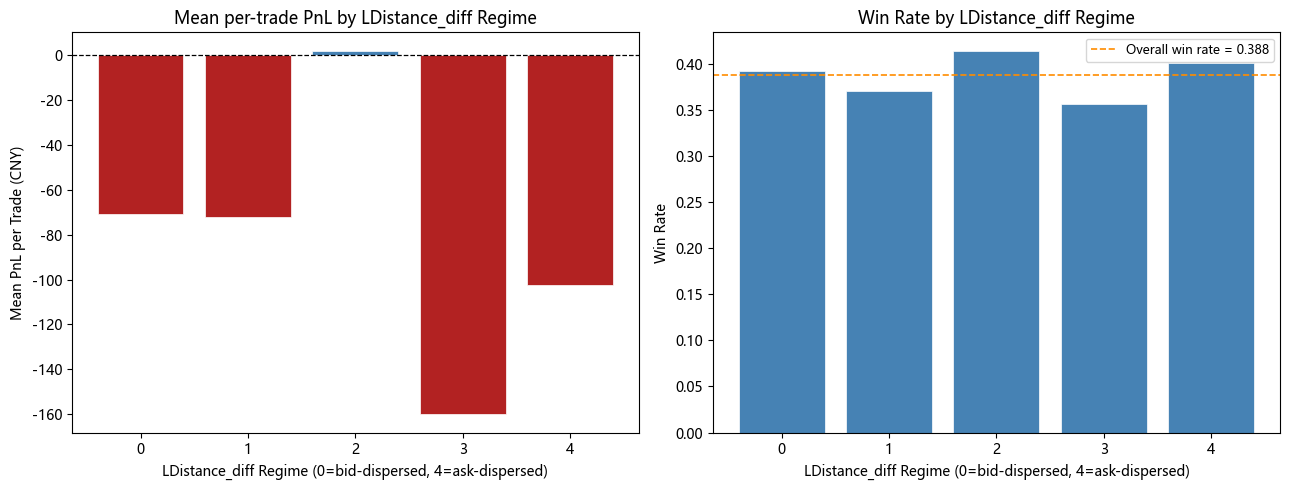

In [ ]:
_overall_win_rate = (trade_log['trade_pnl'] > 0).mean()

_regimes    = regime_stats['entry_regime'].values
_mean_pnl   = regime_stats['mean_pnl'].values
_win_rates  = regime_stats['win_rate'].values
_bar_colors = ['steelblue' if v >= 0 else 'firebrick' for v in _mean_pnl]

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 5))

ax_left.bar(_regimes, _mean_pnl, color=_bar_colors, edgecolor='white', linewidth=0.5)
ax_left.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax_left.set_xlabel('LDistance_diff Regime (0=bid-dispersed, 4=ask-dispersed)')
ax_left.set_ylabel('Mean PnL per Trade (CNY)')
ax_left.set_title('Mean per-trade PnL by LDistance_diff Regime')
ax_left.set_xticks(_regimes)

ax_right.bar(_regimes, _win_rates, color='steelblue', edgecolor='white', linewidth=0.5)
ax_right.axhline(
    _overall_win_rate, color='darkorange', linewidth=1.2, linestyle='--',
    label=f'Overall win rate = {_overall_win_rate:.3f}',
)
ax_right.set_xlabel('LDistance_diff Regime (0=bid-dispersed, 4=ask-dispersed)')
ax_right.set_ylabel('Win Rate')
ax_right.set_title('Win Rate by LDistance_diff Regime')
ax_right.set_xticks(_regimes)
ax_right.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 7.6 — Conclusion

#### Result

ANOVA across the five LDistance_diff regime quintiles: F = 0.47, p = 0.75 — not statistically significant.

#### Regime breakdown table

| Regime | n_trades | Mean PnL/trade | Win Rate |
|---|---|---|---|
| 0 (bid-dispersed) | 924 | -70.7 CNY | 39.3% |
| 1 | 661 | -71.9 CNY | 37.1% |
| 2 (neutral) | 510 | +2.2 CNY | 41.4% |
| 3 | 605 | -160.1 CNY | 35.7% |
| 4 (ask-dispersed) | 870 | -102.5 CNY | 40.1% |

#### Why no regime effect despite strong Section 3 signal

Section 3 measured the *unconditional* predictive power of `LDistance_diff` on random ticks sampled uniformly from the session. Strategy B only enters on ticks where the OLS signal exceeds threshold q — these are ticks where VOI, OIR, and MPB are simultaneously extreme. At those moments, the book asymmetry captured by `LDistance_diff` is already partially reflected in the VOI/OIR signals, so `LDistance_diff` carries no additional conditioning information conditional on Strategy B having already triggered.

#### Verdict: No Regime Effect

**Next step**: LDistance_diff integration is concluded. Both the OLS feature path (Section 6) and the regime conditioner path (Section 7) are exhausted. The notebook's findings on CostToTrade (Section 4: strongly Granger-causes volatility, F = 155.5 at lag 1) provide the basis for this notebook, which implements a CostToTrade-based dynamic threshold rather than further pursuing LDistance_diff.


## Section 8 — CostToTrade as OLS Feature

Tests whether appending `CostToTrade` (the 5-lot market-impact cost computed
in Section 1) as a 14th OLS predictor improves Strategy B.
Two normalisation variants are compared against the 13-feature baseline:

| Attempt | Feature name     | Normalisation          |
|---------|------------------|------------------------|
| 1       | `CTT_raw`        | none (already a fraction) |
| 2       | `CTT_norm`       | divided by bid-ask spread |

Baseline is re-run from `all_features_B` (the Section 6 local rebuild)
so results are directly comparable to the LDistance_diff experiments.
Depends on: `df_s7`, `all_features_B`, `FEATURE_COLS_B`, `_bt_common`
all defined in Section 6.

### 8.1 — Feature Definitions


In [ ]:
# Re-use Section 6 parameters; define CTT feature column names
FEATURE_COLS_B_CTT_RAW  = FEATURE_COLS_B + ["CTT_raw"]
FEATURE_COLS_B_CTT_NORM = FEATURE_COLS_B + ["CTT_norm"]

print(f"Baseline features  ({len(FEATURE_COLS_B)}): {FEATURE_COLS_B}")
print(f"CTT-raw  features  ({len(FEATURE_COLS_B_CTT_RAW)}): {FEATURE_COLS_B_CTT_RAW}")
print(f"CTT-norm features  ({len(FEATURE_COLS_B_CTT_NORM)}): {FEATURE_COLS_B_CTT_NORM}")

# Sanity-check CostToTrade is available in df_s7
assert 'CostToTrade' in df_s7.columns, "CostToTrade missing from df_s7"
print(f"df_s7 CostToTrade: {df_s7['CostToTrade'].describe().to_dict()}")


Baseline features  (13): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm']
CTT-raw  features  (14): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm', 'CTT_raw']
CTT-norm features  (14): ['VOI_t0', 'VOI_t1', 'VOI_t2', 'VOI_t3', 'VOI_t4', 'VOI_t5', 'OIR_t0', 'OIR_t1', 'OIR_t2', 'OIR_t3', 'OIR_t4', 'OIR_t5', 'MPB_norm', 'CTT_norm']
df_s7 CostToTrade: {'count': 2483302.0, 'mean': 0.0002093452067732818, 'std': 0.00010094346490176277, 'min': 2.2572396685238694e-05, '25%': 0.00014398971122620008, '50%': 0.00019378612013293273, '75%': 0.00025416330677846544, 'max': 0.013023022336440593}


### 8.2 — Feature Matrix Construction


In [ ]:
def build_features_B_ctt_raw(df, L=L_B, k=k_B):
    """Strategy B + raw CostToTrade as 14th feature (no normalisation)."""
    n      = len(df)
    spread = df['Spread']
    X_voi  = pd.DataFrame(
        {f"VOI_t{j}": df['VOI'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_oir  = pd.DataFrame(
        {f"OIR_t{j}": df['OIR'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_mpb  = (df['MPB'] / spread).rename('MPB_norm')
    X_ctt  = df['CostToTrade'].rename('CTT_raw')
    y      = compute_response(df, k=k).rename('y')
    out    = pd.concat([X_voi, X_oir, X_mpb, X_ctt, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0
    return out.copy()


def build_features_B_ctt_norm(df, L=L_B, k=k_B):
    """Strategy B + CostToTrade / Spread as 14th feature."""
    n      = len(df)
    spread = df['Spread']
    X_voi  = pd.DataFrame(
        {f"VOI_t{j}": df['VOI'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_oir  = pd.DataFrame(
        {f"OIR_t{j}": df['OIR'].shift(j) / spread for j in range(L + 1)},
        index=df.index,
    )
    X_mpb  = (df['MPB'] / spread).rename('MPB_norm')
    X_ctt  = (df['CostToTrade'] / spread).rename('CTT_norm')
    y      = compute_response(df, k=k).rename('y')
    out    = pd.concat([X_voi, X_oir, X_mpb, X_ctt, y], axis=1).iloc[L + 1 : n - k]
    assert out.isna().sum().sum() == 0
    return out.copy()


_ctt_join = [DAY_COL, SESSION_COL, BID_COL, ASK_COL, 'MidPrice', TIME_COL]

all_features_B_ctt_raw = (
    df_s7.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(build_features_B_ctt_raw)
    .join(df_s7[_ctt_join])
)
assert all_features_B_ctt_raw[FEATURE_COLS_B_CTT_RAW + ['y']].isna().sum().sum() == 0

all_features_B_ctt_norm = (
    df_s7.groupby([DAY_COL, SESSION_COL], group_keys=False)
    .apply(build_features_B_ctt_norm)
    .join(df_s7[_ctt_join])
)
assert all_features_B_ctt_norm[FEATURE_COLS_B_CTT_NORM + ['y']].isna().sum().sum() == 0

print(f"all_features_B_ctt_raw:  {all_features_B_ctt_raw.shape}")
print(f"all_features_B_ctt_norm: {all_features_B_ctt_norm.shape}")

# Feature statistics
print("\nCTT_raw  stats:")
print(all_features_B_ctt_raw['CTT_raw'].describe())
print("\nCTT_norm stats:")
print(all_features_B_ctt_norm['CTT_norm'].describe())


all_features_B_ctt_raw:  (2480706, 21)
all_features_B_ctt_norm: (2480706, 21)

CTT_raw  stats:
count    2.480706e+06
mean     2.092748e-04
std      1.008164e-04
min      2.257240e-05
25%      1.439820e-04
50%      1.937615e-04
75%      2.540835e-04
max      1.302302e-02
Name: CTT_raw, dtype: float64

CTT_norm stats:
count    2.480706e+06
mean     3.337627e-04
std      2.236250e-04
min      1.130250e-04
25%      2.027556e-04
50%      2.594560e-04
75%      3.736838e-04
max      1.706294e-02
Name: CTT_norm, dtype: float64


### 8.3 — Walk-Forward Backtest


In [ ]:
print("Running Strategy B baseline (13 features) ...")
results_B_ctt_base = run_backtest(
    features_df=all_features_B, feature_cols=FEATURE_COLS_B, **_bt_common
)
m_ctt_base = compute_performance_metrics(
    results_B_ctt_base, output_dir=None, verbose=True
)

print("\nRunning Strategy B + CTT_raw (Attempt 1, no normalisation) ...")
results_B_ctt_raw = run_backtest(
    features_df=all_features_B_ctt_raw, feature_cols=FEATURE_COLS_B_CTT_RAW,
    **_bt_common
)
m_ctt_raw = compute_performance_metrics(
    results_B_ctt_raw, output_dir=None, verbose=True
)

print("\nRunning Strategy B + CTT_norm (Attempt 2, divided by spread) ...")
results_B_ctt_norm = run_backtest(
    features_df=all_features_B_ctt_norm, feature_cols=FEATURE_COLS_B_CTT_NORM,
    **_bt_common
)
m_ctt_norm = compute_performance_metrics(
    results_B_ctt_norm, output_dir=None, verbose=True
)


Running Strategy B baseline (13 features) ...
Performance Summary
  Trading days              : 117
  Total round-trips         : 3570
  Mean daily PnL (CNY)      :    -2,544.91
  Std daily PnL             :    15,459.44
  Standard error            :     1,429.23
  t-statistic               :      -1.7806
  p-value (one-tailed)      :     9.61e-01
  Days with profit          :    42 / 117  (35.9%)
  Days with loss            :    75 / 117  (64.1%)
  Mean daily trade volume   :        30.51
  Avg daily Sharpe          :      -0.1725
  Annualized Sharpe         :      -2.6132
  Avg R-squared (training)  :       0.0589
  Win rate per trade        :       38.77%
  Max drawdown (CNY)        :   385,992.17

Running Strategy B + CTT_raw (Attempt 1, no normalisation) ...
Performance Summary
  Trading days              : 117
  Total round-trips         : 3588
  Mean daily PnL (CNY)      :    -2,886.73
  Std daily PnL             :    14,177.62
  Standard error            :     1,310.72
  t-stat

### 8.4 — Comparison Table


In [ ]:
def _win_rate_days_ctt(results):
    days = sorted(results.keys())
    return round(sum(1 for d in days if results[d]['daily_pnl'] > 0) / len(days) * 100, 1)


KEY_METRICS_CTT = [
    'mean_daily_pnl', 'std_daily_pnl', 't_stat', 'p_value',
    'annualized_sharpe', 'win_rate_per_trade',
    'n_trades', 'mean_daily_trade_volume', 'max_drawdown',
]

ctt_summary = pd.DataFrame({
    'B baseline (13 feat)': {
        'Annualised Sharpe':        round(m_ctt_base['annualized_sharpe'],  3),
        'Mean daily PnL (CNY)':     round(m_ctt_base['mean_daily_pnl'],     1),
        'Std daily PnL (CNY)':      round(m_ctt_base['std_daily_pnl'],      1),
        't-stat':                   round(m_ctt_base['t_stat'],             3),
        'p-value':                  round(m_ctt_base['p_value'],            4),
        'Win rate (% days > 0)':    _win_rate_days_ctt(results_B_ctt_base),
        'Total trades':             int(m_ctt_base['n_trades']),
        'Mean daily volume':        round(m_ctt_base['mean_daily_trade_volume'], 1),
        'Max drawdown (CNY)':       round(m_ctt_base['max_drawdown'],      0),
    },
    'B + CTT_raw (Attempt 1)': {
        'Annualised Sharpe':        round(m_ctt_raw['annualized_sharpe'],   3),
        'Mean daily PnL (CNY)':     round(m_ctt_raw['mean_daily_pnl'],      1),
        'Std daily PnL (CNY)':      round(m_ctt_raw['std_daily_pnl'],       1),
        't-stat':                   round(m_ctt_raw['t_stat'],              3),
        'p-value':                  round(m_ctt_raw['p_value'],             4),
        'Win rate (% days > 0)':    _win_rate_days_ctt(results_B_ctt_raw),
        'Total trades':             int(m_ctt_raw['n_trades']),
        'Mean daily volume':        round(m_ctt_raw['mean_daily_trade_volume'],  1),
        'Max drawdown (CNY)':       round(m_ctt_raw['max_drawdown'],       0),
    },
    'B + CTT_norm (Attempt 2)': {
        'Annualised Sharpe':        round(m_ctt_norm['annualized_sharpe'],  3),
        'Mean daily PnL (CNY)':     round(m_ctt_norm['mean_daily_pnl'],     1),
        'Std daily PnL (CNY)':      round(m_ctt_norm['std_daily_pnl'],      1),
        't-stat':                   round(m_ctt_norm['t_stat'],             3),
        'p-value':                  round(m_ctt_norm['p_value'],            4),
        'Win rate (% days > 0)':    _win_rate_days_ctt(results_B_ctt_norm),
        'Total trades':             int(m_ctt_norm['n_trades']),
        'Mean daily volume':        round(m_ctt_norm['mean_daily_trade_volume'], 1),
        'Max drawdown (CNY)':       round(m_ctt_norm['max_drawdown'],      0),
    },
}).T

ctt_summary.index.name = 'Strategy'
print('\n=== CTT Feature Comparison ===')
display(ctt_summary)



=== CTT Feature Comparison ===


,Annualised Sharpe,Mean daily PnL (CNY),Std daily PnL (CNY),t-stat,p-value,Win rate (% days > 0),Total trades,Mean daily volume,Max drawdown (CNY)
Strategy,,,,,,,,,
B baseline (13 feat),-2.613,-2544.9,15459.4,-1.781,0.9612,35.9,3570.0,30.5,385992.0
B + CTT_raw (Attempt 1),-3.232,-2886.7,14177.6,-2.202,0.9852,36.8,3588.0,30.7,405324.0
B + CTT_norm (Attempt 2),-3.360,-3082.2,14561.0,-2.290,0.9881,32.5,3605.0,30.8,452549.0


### 8.5 — Cumulative PnL Plot


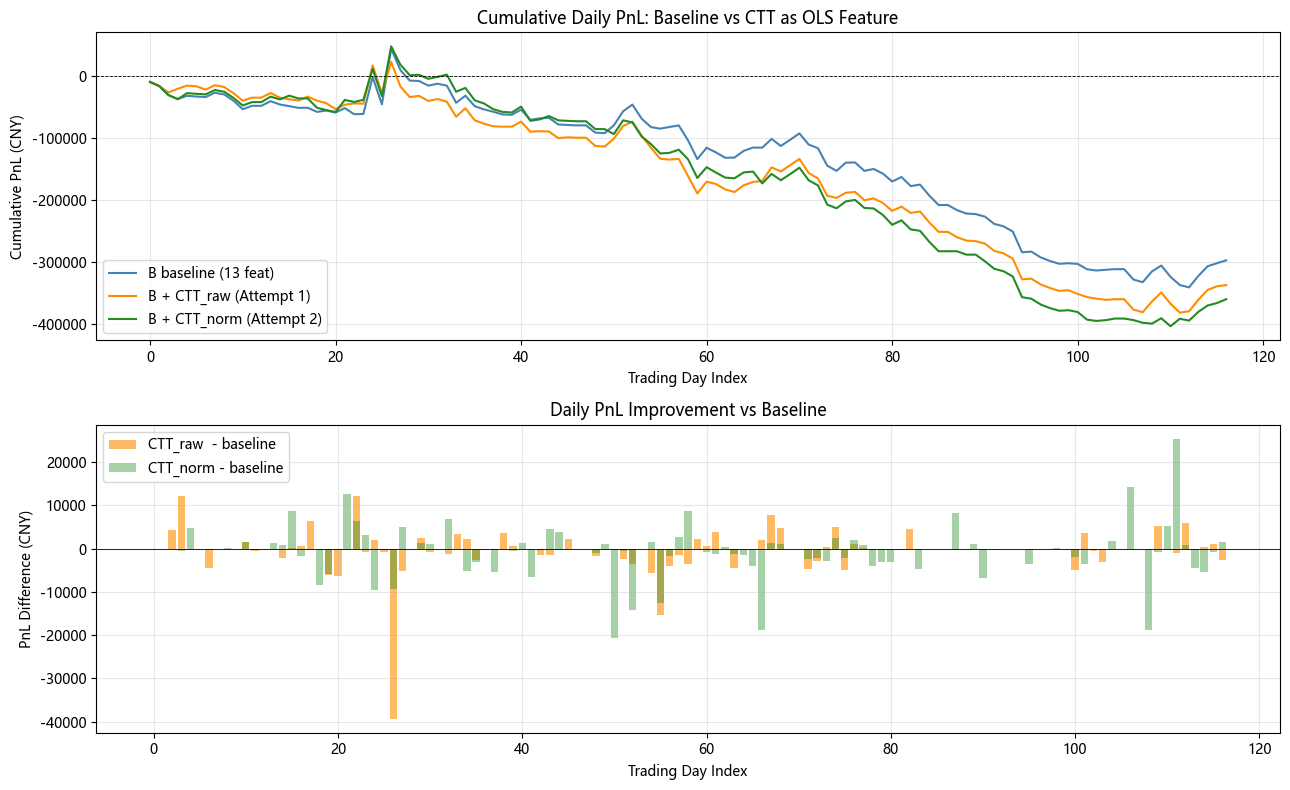

Comparison plot saved to results_2018/B_vs_B_CTT_feature_comparison.png


In [ ]:
_days_base_ctt  = sorted(results_B_ctt_base.keys())
_days_ctt_raw   = sorted(results_B_ctt_raw.keys())
_days_ctt_norm  = sorted(results_B_ctt_norm.keys())

_pnl_base_ctt   = np.array([results_B_ctt_base[d]['daily_pnl']  for d in _days_base_ctt])
_pnl_ctt_raw    = np.array([results_B_ctt_raw[d]['daily_pnl']   for d in _days_ctt_raw])
_pnl_ctt_norm   = np.array([results_B_ctt_norm[d]['daily_pnl']  for d in _days_ctt_norm])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# Top: cumulative PnL
ax1.plot(np.cumsum(_pnl_base_ctt),  color='steelblue',  linewidth=1.5, label='B baseline (13 feat)')
ax1.plot(np.cumsum(_pnl_ctt_raw),   color='darkorange', linewidth=1.5, label='B + CTT_raw (Attempt 1)')
ax1.plot(np.cumsum(_pnl_ctt_norm),  color='forestgreen',linewidth=1.5, label='B + CTT_norm (Attempt 2)')
ax1.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax1.set_title('Cumulative Daily PnL: Baseline vs CTT as OLS Feature')
ax1.set_xlabel('Trading Day Index')
ax1.set_ylabel('Cumulative PnL (CNY)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom: daily PnL difference (CTT_raw vs baseline)
min_len = min(len(_pnl_base_ctt), len(_pnl_ctt_raw))
_diff_raw  = _pnl_ctt_raw[:min_len]  - _pnl_base_ctt[:min_len]
_diff_norm = _pnl_ctt_norm[:min_len] - _pnl_base_ctt[:min_len]
ax2.bar(range(min_len), _diff_raw,  alpha=0.6, color='darkorange',  label='CTT_raw  - baseline')
ax2.bar(range(min_len), _diff_norm, alpha=0.4, color='forestgreen', label='CTT_norm - baseline')
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_title('Daily PnL Improvement vs Baseline')
ax2.set_xlabel('Trading Day Index')
ax2.set_ylabel('PnL Difference (CNY)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results_2018/B_vs_B_CTT_feature_comparison.png', dpi=150)
plt.show()
print('Comparison plot saved to results_2018/B_vs_B_CTT_feature_comparison.png')


### 8.6 — OLS Coefficient Stability: CostToTrade

Per-day OLS coefficient for `CTT_raw` and `CTT_norm` across all 117 trading days.
A consistent sign (all positive or all negative) indicates a genuine signal; mixed signs indicate noise.


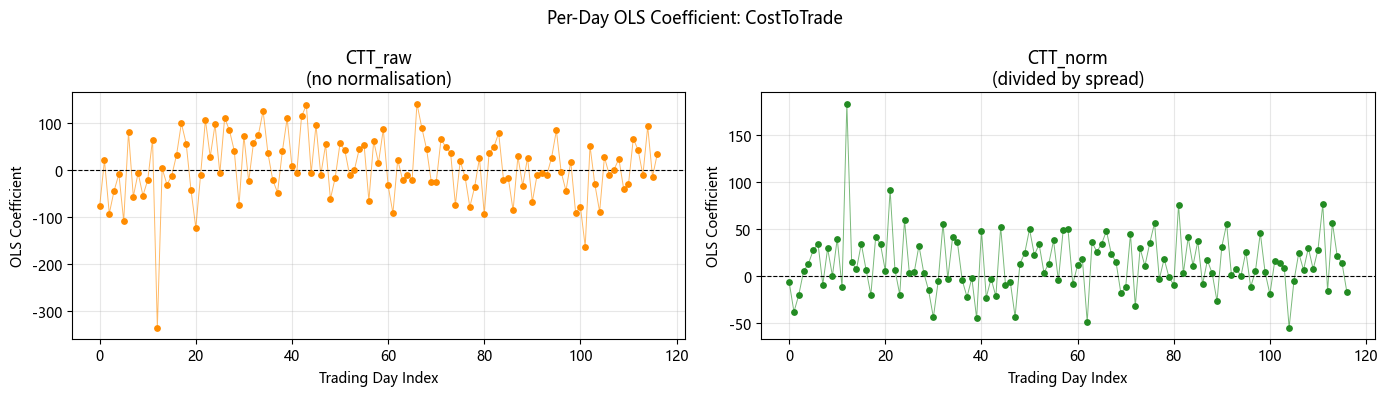

Feature                    Pos   Neg     Mean      Std
CTT_raw                      58    59    3.9320   67.8297
CTT_norm                     77    40   13.4165   31.9771


In [ ]:
_ctt_raw_idx  = FEATURE_COLS_B_CTT_RAW.index('CTT_raw')   + 1  # +1 for intercept
_ctt_norm_idx = FEATURE_COLS_B_CTT_NORM.index('CTT_norm')  + 1

_days_sorted_ctt = sorted(results_B_ctt_raw.keys())

def _get_coef_ctt(results, feat_idx, days):
    vals = []
    for d in days:
        c = results[d].get('coefs')
        vals.append(c[feat_idx] if (c is not None and len(c) > feat_idx) else np.nan)
    return vals

_coef_ctt_raw  = _get_coef_ctt(results_B_ctt_raw,  _ctt_raw_idx,  _days_sorted_ctt)
_coef_ctt_norm = _get_coef_ctt(results_B_ctt_norm, _ctt_norm_idx, _days_sorted_ctt)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

for ax, coefs, label, color in zip(
    [ax1, ax2],
    [_coef_ctt_raw, _coef_ctt_norm],
    ['CTT_raw\n(no normalisation)', 'CTT_norm\n(divided by spread)'],
    ['darkorange', 'forestgreen'],
):
    xs = range(len(_days_sorted_ctt))
    ax.scatter(xs, coefs, color=color, s=15, zorder=3)
    ax.plot(xs, coefs, color=color, linewidth=0.7, alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Trading Day Index')
    ax.set_ylabel('OLS Coefficient')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-Day OLS Coefficient: CostToTrade', fontsize=12)
plt.tight_layout()
plt.savefig('results_2018/B_CTT_feature_coef_stability.png', dpi=150)
plt.show()

# Sign consistency summary
print('Feature                    Pos   Neg     Mean      Std')
for label, coefs in [('CTT_raw', _coef_ctt_raw), ('CTT_norm', _coef_ctt_norm)]:
    valid = [c for c in coefs if c == c]
    pos   = sum(1 for c in valid if c > 0)
    neg   = sum(1 for c in valid if c < 0)
    print(f'{label:<26} {pos:>4}  {neg:>4}  {np.mean(valid):>8.4f}  {np.std(valid):>8.4f}')


### 8.7 — Interpretation

#### Results Summary

| Strategy | Sharpe | Mean PnL/day | Win rate (days) | Total trades |
|---|---|---|---|---|
| B baseline (13 feat) | -2.613 | -2,545 CNY | 35.9% | 3,570 |
| B + CTT_raw (Attempt 1) | -3.232 | -2,887 CNY | 36.8% | 3,588 |
| B + CTT_norm (Attempt 2) | -3.360 | -3,082 CNY | 32.5% | 3,605 |

#### Coefficient Sign Consistency

| Feature | Positive days | Negative days | Mean coef | Std coef |
|---|---|---|---|---|
| CTT_raw | 58 | 59 | 3.93 | 67.83 |
| CTT_norm | 77 | 40 | 13.42 | 31.98 |

#### Diagnosis

Both attempts **worsen** Sharpe relative to the 13-feature baseline — matching the diagnostic row: *Sharpe worsened, coefficient sign mixed → CTT is noisy at the OLS level*.

- **CTT_raw**: 58 positive vs 59 negative days — effectively a coin flip, with mean coefficient 3.93 dwarfed by standard deviation 67.83. No directional signal.
- **CTT_norm**: 77 positive vs 40 negative days, mean = 13.42. The positive bias is superficially encouraging, but std (31.98) is more than twice the mean, and the positive-leaning sign does not translate to profit: Sharpe worsens from -2.613 to -3.360, and win rate falls to 32.5%.
- Trade count is essentially unchanged (~3,570 → 3,605 across all three runs): CTT is not shifting the OLS prediction distribution meaningfully, confirming it carries negligible marginal information about future mid-price direction once VOI, OIR, and MPB are already in the model.

#### Root Cause

CostToTrade measures the *cost* of execution, not the *direction* of subsequent price moves. For CTT to add value as an OLS predictor, high-cost environments would need to Granger-cause directional returns — not just volatility. The Granger-causality results (F = 155.5 at lag 1) show CTT predicts **volatility**, which is symmetric and direction-agnostic. Adding a volatility proxy to a directional OLS regression introduces noise without providing a sign.

#### Verdict: CTT Is Not an OLS Feature

Neither normalisation variant improves performance. The correct role for CostToTrade in this framework is as a **threshold adjuster** (Section 4): requiring a higher OLS signal threshold when trading is expensive — not as a directional predictor.

**Conclusion**: CostToTrade OLS experiments are complete. The Section 4 dynamic threshold strategy (B-CTT) remains the best-performing variant tested; appending CTT to the OLS feature set provides no benefit and mildly hurts performance.
